# **Project 02**

## **Bài toán số 1 - Recommendation**

**Cài đặt**

In [1]:
# !pip install pyvi
# !pip install gensim

**Import thư viện**

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from seaborn._core.typing import default
from mpl_toolkits.mplot3d import Axes3D
import warnings
warnings.filterwarnings('ignore')
import joblib
import re, os, math, unicodedata, builtins
from scipy import stats
from scipy.special import inv_boxcox
from scipy.stats import skew

from functools import reduce
from itertools import combinations

from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, OneHotEncoder, FunctionTransformer, QuantileTransformer
from sklearn.linear_model import LinearRegression, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, IsolationForest
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, silhouette_score
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

from bs4 import BeautifulSoup
from pyvi import ViTokenizer
from pyvi.ViTokenizer import tokenize
from gensim import models as gensim_models
from gensim import corpora, similarities
import gensim.similarities as gensim_similarities

from sklearn.feature_extraction.text import HashingVectorizer, TfidfTransformer

import streamlit as st



**Copy và đọc dữ liệu**

In [3]:
df = pd.read_csv(
    'clean_data_without_outliers_with_skewness.csv', 
    encoding='utf-8-sig'
)

In [4]:
# Định nghĩa các hàm phụ trợ để xử lý ép kiểu và làm tròn (tương đương F.round + F.cast)
def fmt_num(series, prefix="", suffix=""):
    # Ép kiểu sang float, làm tròn 2 chữ số và nối chuỗi
    # Xử lý trường hợp NaN để tránh lỗi
    return prefix + series.fillna(0).round(2).astype(str) + suffix

def fmt_int(series, suffix=""):
    return series.fillna(0).astype(int).astype(str) + suffix

# Tạo danh sách các cột đã được định dạng
parts = [
    df["tieu_de"].fillna(""),
    df["mo_ta"].fillna(""),
    fmt_num(df["dien_tich_dat"], "dien_tich_dat_", "_m2"),
    fmt_num(df["dien_tich_su_dung"], "dien_tich_su_dung_", "_m2"),
    fmt_num(df["chieu_ngang"], "chieu_ngang_", "_m"),
    fmt_int(df["tong_so_tang"], "_tang"),
    fmt_int(df["so_phong_ngu"], "_phong_ngu"),
    df["loai_hinh"].fillna(""),
    df["giay_to_phap_ly"].fillna(""),
    df["tinh_trang_noi_that"].fillna(""),
    "huong_cua_chinh_" + df["huong_cua_chinh"].fillna(""),
    df["dac_diem"].fillna(""),
    df["dia_chi_cu"].fillna(""),
    df["dia_chi_moi"].fillna(""),
    fmt_num(df["gia_ban"], "gia_ban_", "_ty")
]

# Nối tất cả lại bằng khoảng trắng (tương đương F.concat_ws)
df["description"] = parts[0]
for part in parts[1:]:
    df["description"] = df["description"] + " " + part

# Xử lý Regex và Trim (tương đương F.regexp_replace và F.trim)
pattern_to_remove = r"chua_xac_dinh|hien_trang_khac"
df["description"] = (
    df["description"]
    .str.replace(pattern_to_remove, "", regex=True) # Replace theo pattern
    .str.replace(r'\s+', ' ', regex=True)          # Thu gọn nhiều khoảng trắng thừa do replace tạo ra
    .str.strip()                                   # Trim đầu cuối
)

**Đánh lại chỉ mục từ 0**

In [5]:
# df = df.reset_index(names='id')
df = df.reset_index(drop=True)
df['id'] = df.index.values

**Sử dụng stop-word**

In [6]:
STOP_WORD_FILE = 'files/vietnamese-stopwords.txt'
with open(STOP_WORD_FILE, 'r', encoding='utf-8') as file:
    stop_words = file.read()

stop_words = stop_words.split('\n')

**Làm sạch dữ liệu HTML và icon**

In [7]:
def clean_html_icon(text):
    if pd.isna(text) or text == "":
        return ""

    # Loại bỏ các thẻ HTML
    # Dùng 'lxml' hoặc 'html.parser' tùy thư viện bạn đã cài
    soup = BeautifulSoup(text, "html.parser")
    text = soup.get_text()

    # Loại bỏ Emojis và các ký tự biểu tượng đặc biệt
    # Giữ lại ký tự Latin, số và dải Unicode tiếng Việt (\u00C0-\u1EF9)
    text = re.sub(r'[^\x00-\x7F\u00C0-\u1EF9]+', ' ', text)

    # Làm sạch khoảng trắng và xuống dòng
    text = text.replace("\n", " ")
    text = re.sub(r"\s+", " ", text)

    return text.strip().lower()

# Áp dụng vào DataFrame bằng .apply()
df["description_clean"] = df["description"].apply(clean_html_icon)

# Hiển thị kết quả (không cắt chữ)
pd.set_option('display.max_colwidth', None)

**Word_tokenize**

In [8]:
def vn_tokenize(text):
    if text is None:
        return ""
    return ViTokenizer.tokenize(text)

# Áp dụng cho pandas DataFrame
df["description_clean"] = df["description_clean"].apply(vn_tokenize)

In [9]:
df[["id", "description_clean"]].head(5)

,id,description_clean
0,0,"nhà hẻm cách đường mặt_tiền 20m nhà hẻm cách đường mặt_tiền 20m nhà ở khu_vực cao không ngập_lụt , khu dân_cư yên_tĩnh , ... gần trường_học cán_bộ tphcm , siêu_thị , chợ , ... . giá 2 tỷ 850 còn thương_lượng sổ hồng chính chủ lh * * * dien_tich_dat_18 . 0_m2 dien_tich_su_dung_18 . 0_m2 chieu_ngang_3 . 0_m 1_tang 2_phong_ngu nha_ngo_hem da_co_so huong_cua_chinh_bac phuong_12_quan_binh_thanh phuong_binh_thanh gia_ban_2 . 85_ty"
1,1,"nhà hẻm cách mặt_tiền 20m nhà trong hẻm cách đường lớn 20m khu dân_cư yên_tĩnh , không ngập_lụt , gần trường_học cán_bộ tphcm , siêu thi , chợ , ... diện_tích 3x 6,5 m giá 2 tỷ 850 còn thương_lượng sổ hồng chính chủ lh * * * dien_tich_dat_20 . 0_m2 dien_tich_su_dung_20 . 0_m2 chieu_ngang_3 . 08_m 2_tang 2_phong_ngu nha_ngo_hem huong_cua_chinh_bac phuong_12_quan_binh_thanh phuong_binh_thanh gia_ban_2 . 85_ty"
2,2,"nhà mới xây 3x11 , 5 , 2 tầng , diện_tích sử_dụng 68m2 , nội_thất đầy_đủ nhà mới xây , 2 phòng ngủ rộng + ban_công rộng , 2 toilet , phòng khách , phòng bếp + bàn ăn nội_thất cao_cấp , giường , tủ , bếp , tủ_lạnh tivi , máy_lạnh , máy_giặt , ghế sofa , bàn ăn , nước nóng năng_lượng mặt_trời , chỉ cần xách valy vào ở liền . hẻm ba_gác , cách hẻm ô_tô 20m bán_kính 500m tiện_ích đầy_đủ chợ , trường_học , phòng gym , siêu_thị emart , đại_lộ phạm văn đồng , đi sân_bay chưa tới 10 phút pháp_lý chuẩn , khu dân_trí cao , yên_tĩnh . sổ sẵn , hoàn_công đủ , công_chứng trong ngày . hỗ_trợ vay bank dien_tich_dat_34 . 0_m2 dien_tich_su_dung_68 . 0_m2 chieu_ngang_2 . 96_m 2_tang 2_phong_ngu nha_ngo_hem da_co_so noi_that_cao_cap huong_cua_chinh_dong_bac phuong_11_quan_binh_thanh phuong_binh_loi_trung gia_ban_5 . 96_ty"
3,3,"nơ trang long 2 tầng đúc 2pn 2wc full nội_thất giáp quận 1 3.9 tỏi quốc kiệt nhà phố một buổi sáng mở_cửa , vài bước chân là tới bệnh_viện gia định khu trung_tâm mà giá còn mềm thế này không nhanh là tiếc . nơ trang long p . gia định bình thạnh hẻm ô_tô 2 tầng đúc 2pn 2wc full nội_thất giáp quận 1 3.9 tỏi vị_trí : đường nơ trang long , ngay bệnh_viện gia định , ung_bướu , sát mặt_tiền phan đăng lưu . từ nhà chạy vài phút là qua quận 1 đi làm , đi học hay kinh_doanh đều tiện . khu dân_cư hiện_hữu , gần trường_học , ngân_hàng , tiện_ích đầy_đủ . diện_tích : 20m ( 3.8 x6 ) nhỏ gọn nhưng bố_trí cực_kỳ hợp_lý . kết_cấu : 1 trệt 1 lầu đúc kiên_cố . 2 phòng ngủ , 2wc . nhà mới keng , sáng_sủa , vô ở liền không cần sửa_sang . nội_thất : đầy_đủ cơ_bản khách chỉ cần xách vali vào là ở . hẻm : hẻm sạch_sẽ , an_ninh , dân_trí cao . pháp_lý : sổ hồng riêng , hoàn_công đủ công_chứng ngay . giá chào : 3.9 tỏi khu giáp quận 1 mà tầm giá này cực hiếm . anh_chị đang tìm căn nhỏ gọn , tài_chính vừa_phải , ở trung_tâm bình thạnh đây là lựa_chọn rất đáng xem . dien_tich_dat_20 . 0_m2 dien_tich_su_dung_40 . 0_m2 chieu_ngang_3 . 33_m 2_tang 2_phong_ngu nha_ngo_hem da_co_so noi_that_day_du huong_cua_chinh_dong_bac phuong_13_quan_binh_thanh phuong_binh_loi_trung gia_ban_3 . 9_ty"
4,4,"gấp bán "" 6.7 tỷ giảm về 6.1 tỷ "" - bán đất tặng nhà 2 tầng 50m2 p . 6 vị_trí hoàng hoa thám p . 6 bình thạnh + diện_tích : 4.2 m x 12m + hiện_trạng : 2 tầng . có 2pn + nhà cũ theo thời_gian phù_hợp phương_án cải_tạo lại hoặc xây_dựng mới + khu xây_dựng 5 tầng + hẻm xe_hơi "" nhận ký_gửi và hỗ_trợ định_giá miễn_phí nhà_đất sài_gòn "" miễn tiếp môi_giới dien_tich_dat_50 . 0_m2 dien_tich_su_dung_90 . 0_m2 chieu_ngang_4 . 17_m 2_tang 2_phong_ngu nha_ngo_hem da_co_so hoan_thien_co_ban huong_cua_chinh_tay hem_xe_hoi phuong_6_quan_binh_thanh phuong_binh_loi_trung gia_ban_6 . 19_ty"


**TF-IDF + COSINE SIMILARITY**

**Theo 3 bước:**
1. Tách từ --> Tokenizer (Biến chuỗi thành mảng các từ)
2. HashingVectorizer
3. Tính TF-IDF (TfidfTransformer)

In [10]:
# Bước 1 + 2: Tokenize + HashingTF (gộp luôn bằng HashingVectorizer)
vectorizer = HashingVectorizer(
    n_features=10000,   # giống numFeatures
    tokenizer=lambda x: x.split(),  # vì đã có text dạng "nhà_phố đẹp"
    lowercase=False     # giữ nguyên tiếng Việt
)

X_tf = vectorizer.transform(df["description_clean"])

# Bước 3: IDF
tfidf = TfidfTransformer()
X_tfidf = tfidf.fit_transform(X_tf)


### **Chuẩn hóa Vector (Normalizing)**
Bước này giúp biến phép tính Cosine phức tạp thành phép nhân ma trận đơn giản

In [11]:
from sklearn.preprocessing import normalize

# Lấy ma trận TF-IDF (X_tfidf đã tạo ở bước trước)
X_norm = normalize(X_tfidf, norm='l2')

# Gán lại vào DataFrame
df["normFeatures"] = list(X_norm)

# Lấy dạng giống (id, vector)
features_list = list(zip(df["id"], df["normFeatures"]))

# Xem thử
print(features_list[:5])

[(0, <1x10000 sparse matrix of type '<class 'numpy.float64'>'
	with 49 stored elements in Compressed Sparse Row format>), (1, <1x10000 sparse matrix of type '<class 'numpy.float64'>'
	with 52 stored elements in Compressed Sparse Row format>), (2, <1x10000 sparse matrix of type '<class 'numpy.float64'>'
	with 96 stored elements in Compressed Sparse Row format>), (3, <1x10000 sparse matrix of type '<class 'numpy.float64'>'
	with 150 stored elements in Compressed Sparse Row format>), (4, <1x10000 sparse matrix of type '<class 'numpy.float64'>'
	with 73 stored elements in Compressed Sparse Row format>)]


**Thử tìm căn nhà tương tự với ID=10**

In [12]:
df.loc[df["id"] == 10, ["id", "description_clean"]]

,id,description_clean
10,10,"hiếm , hẻm xe_hơi , ~ 40m2 , nhà 2tầng bạch đằng , gần trường_học , - nhà bạch đằng , bình_thạnh - diện_tích ~ 40m2 xe_hơi đến tận cửa_nhà kết_cấu : 2 tầng . pk - bếp - pn - 2 wc bê_tông cốt thép chắc_chắn có_thể lên tầng . cách vài bước chân đến trường_học cách vài bước chân ra đường lớn bạch đằng thuận_tiện đi khắp các quận vị_trí chợ bà chiểu , ngã tư hàng xanh ... shr , vuông a4 - hcđ - công_chứng nhanh dien_tich_dat_40 . 0_m2 dien_tich_su_dung_40 . 0_m2 chieu_ngang_3 . 0_m 2_tang 2_phong_ngu nha_ngo_hem da_co_so huong_cua_chinh_dong_bac hem_xe_hoi phuong_15_quan_binh_thanh phuong_gia_dinh gia_ban_5 . 45_ty"


In [13]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

# Giả sử bạn đã có:
# X_norm (ma trận normalized TF-IDF)
# df (DataFrame chứa id, description_clean)

target_id = 10  # Changed target_id from 10 to 0, as 10 might not exist after data cleaning

# Lấy index của dòng có id = 10
target_idx = df.index[df["id"] == target_id][0]

# Lấy vector của target
target_vector = X_norm[target_idx]

# Tính cosine similarity với toàn bộ dataset
sk_similarities = cosine_similarity(target_vector, X_norm).flatten()

# Gán vào DataFrame
df["similarity_score"] = sk_similarities

# Lọc bỏ chính nó + lấy top 5
recommendations = (
    df[df["id"] != target_id]
    .sort_values(by="similarity_score", ascending=False)
    [["id", "description_clean", "similarity_score"]]
    .head(5)
)

recommendations

,id,description_clean,similarity_score
2335,2335,"hẻm xh bạch đằng - diện_tích 36m2 - 2 tầng . - 5,45 tỷ hẻm xe_hơi bạch đằng diện_tích 36m2 kết_cấu : 2 tầng . bê_tông cốt thép chắc_chắn có_thể lên tầng . vị_trí chợ bà chiểu , ngã tư hàng xanh ... shr , vuông a4 - công_chứng nhanh hướng nam gi . a : 5,45 ty lh : * * * dien_tich_dat_36 . 0_m2 dien_tich_su_dung_50 . 5_m2 chieu_ngang_2 . 77_m 2_tang 2_phong_ngu nha_ngo_hem da_co_so noi_that_day_du huong_cua_chinh_bac hem_xe_hoi phuong_15_quan_binh_thanh phuong_gia_dinh gia_ban_5 . 45_ty",0.559432
1937,1937,"hxh - ngay hàng xanh - 40m2 - nhỉnh 5 tỏi - 2 tầng btct - shr hxh - ngay hàng xanh - 40m2 - nhỉnh 5 tỏi kết_cấu : 2 tầng . pk - bếp - 2pn - 2 wc bê_tông cốt thép chắc_chắn có_thể lên tầng . vị_trí chợ bà chiểu , ngã tư hàng xanh ... shr , vuông a4 - hcđ - công_chứng nhanh hướng nam dien_tich_dat_40 . 0_m2 dien_tich_su_dung_59 . 4_m2 chieu_ngang_3 . 08_m 2_tang 2_phong_ngu nha_ngo_hem da_co_so noi_that_day_du huong_cua_chinh_nam hem_xe_hoi phuong_15_quan_binh_thanh phuong_gia_dinh gia_ban_5 . 0_ty",0.520231
2382,2382,"bạch đằng , p . 15 bình_thạnh - 2 tầng - 5.45 tỷ chính chủ cần bán gấp căn nhà vị_trí đẹp tại đường bạch đằng , phường 15 , quận bình_thạnh . vị_trí đắc_địa : hẻm xe_hơi đỗ cửa . ngay sát chợ bà chiểu , ngã tư hàng xanh . di_chuyển sang quận 1 chỉ 5 phút , giao_thông cực_kỳ thuận_tiện . diện_tích : 36m ( 2.9 m x 13m ) . đất vuông_vức chuẩn a4 , không lỗi phong_thủy . kết_cấu : nhà 1 trệt 1 lầu , đúc bê_tông cốt thép ( btct ) chắc_chắn . hiện_trạng : phòng khách , bếp , phòng ngủ rộng , 2 wc . móng nhà kiên_cố , có_thể xây lên thêm tầng thoải_mái . pháp_lý : sổ hồng riêng chính chủ , đã hoàn_công đầy_đủ , công_chứng sang_tên ngay trong ngày . hướng : nam ( cực_kỳ mát_mẻ ) . giá bán : 5.45 tỷ ( thương_lượng cho khách thiện_chí ) . dien_tich_dat_36 . 0_m2 dien_tich_su_dung_50 . 5_m2 chieu_ngang_2 . 77_m 2_tang 2_phong_ngu nha_ngo_hem da_co_so huong_cua_chinh_dong_bac hem_xe_hoi phuong_15_quan_binh_thanh phuong_gia_dinh gia_ban_5 . 45_ty",0.450069
2270,2270,"hiếm - hẻm xe_hơi - nhà 2 tầng - 36m2 . chỉ nhỉnh 5 tỉ . hiếm - hẻm xe_hơi - nhà 2 tầng kiên_cố - 36m2 . - kết_cấu 1 trệt 1 lầu - 1pn 2 wc , có_thể tải tạo nâng tầng . - gần hàng xanh - bạch đằng . thuận_tiện di_chuyển khắp các ngã . - hẻm xe_hơi đỗ cửa - khu_vực dân_trí an_ninh - shr , công_chứng ngay . dien_tich_dat_36 . 0_m2 dien_tich_su_dung_50 . 5_m2 chieu_ngang_2 . 77_m 2_tang 1_phong_ngu nha_ngo_hem da_co_so huong_cua_chinh_dong_bac hem_xe_hoi phuong_15_quan_binh_thanh phuong_gia_dinh gia_ban_5 . 45_ty",0.442845
2434,2434,"chỉ 5.25 tỷ - 34 / 48m2 - bạch đằng - bình_thạnh - chỉ 5.25 tỷ - 34 / 48m2 - bạch đằng - bình_thạnh - bạch đằng 34 / 48 2 3 16 5.25 tỷ bình thạnh hcm kết_cấu 1 trệt 1 lầu . gồm : 2pn , 2wc , bếp , ban_công , phòng khách , vào ở ngay . + vị_trí đẹp , hẻm ba_gác , tiện_ích xung_quanh không thiếu_gì . + sổ hồng riêng , pháp_lý sạch , hoàn_công đầy_đủ , công_chứng mua_bán giao nhà ngay . dien_tich_dat_48 . 0_m2 dien_tich_su_dung_77 . 21_m2 chieu_ngang_3 . 0_m 2_tang 2_phong_ngu nha_ngo_hem da_co_so huong_cua_chinh_tay_bac phuong_2_quan_binh_thanh phuong_gia_dinh gia_ban_5 . 25_ty",0.376114


### **Gensim**

**Chuẩn bị dữ liệu cho Gensim**\
Chuyển cột description_clean đã được tokenize (tách từ) thành dạng danh sách các từ (List of Strings).

In [14]:
# Lấy 2 cột cần xử lý
pdf = df[["id", "description_clean"]]

# Định nghĩa hàm làm sạch và tách từ cho từng dòng
def clean_and_tokenize(text):
    if text is None:
        return ""

    # Thay thế gạch dưới bằng khoảng trắng để ViTokenizer nhận diện từ ghép tốt hơn
    text_clean = text.replace("_", " ")

    # Tokenize tiếng Việt (sân thượng -> sân_thượng)
    tokenized = ViTokenizer.tokenize(text_clean)

    # Custom nối lại các cụm số + đơn vị (ví dụ: dài_3m, ngang_5m)
    # Regex này tìm từ 'dài' hoặc 'ngang' theo sau là khoảng trắng và con số
    final_text = re.sub(r'(dài|ngang|rộng)\s(\d+)', r'\1_\2', tokenized)

    return final_text

# Áp dụng hàm xử lý cho toàn bộ cột trong Pandas
pdf["description_clean"] = pdf["description_clean"].apply(clean_and_tokenize)

# Chuyển chuỗi thành danh sách từ (List of Lists) để Gensim hiểu
documents = [doc.split() for doc in pdf["description_clean"]]


**Xây dựng mô hình TF-IDF với Gensim**

Gensim sử dụng cấu trúc Dictionary để quản lý từ điển và Corpus để lưu trữ tần suất xuất hiện

In [15]:
# Tạo từ điển (Dictionary)
dictionary = corpora.Dictionary(documents)

# Chuyển văn bản thành dạng Bag-of-Words (BoW)
corpus = [dictionary.doc2bow(doc) for doc in documents]

# Huấn luyện mô hình TF-IDF
tfidf_model = gensim_models.TfidfModel(corpus)
corpus_tfidf = tfidf_model[corpus]

**Tính toán Cosine Similarity**

Gensim cung cấp lớp MatrixSimilarity cực kỳ tối ưu để tìm kiếm những căn nhà tương đồng

**Thử tìm căn nhà tương tự với ID=10**

In [16]:
df.loc[df["id"] == 10, ["id", "description_clean"]]

,id,description_clean
10,10,"hiếm , hẻm xe_hơi , ~ 40m2 , nhà 2tầng bạch đằng , gần trường_học , - nhà bạch đằng , bình_thạnh - diện_tích ~ 40m2 xe_hơi đến tận cửa_nhà kết_cấu : 2 tầng . pk - bếp - pn - 2 wc bê_tông cốt thép chắc_chắn có_thể lên tầng . cách vài bước chân đến trường_học cách vài bước chân ra đường lớn bạch đằng thuận_tiện đi khắp các quận vị_trí chợ bà chiểu , ngã tư hàng xanh ... shr , vuông a4 - hcđ - công_chứng nhanh dien_tich_dat_40 . 0_m2 dien_tich_su_dung_40 . 0_m2 chieu_ngang_3 . 0_m 2_tang 2_phong_ngu nha_ngo_hem da_co_so huong_cua_chinh_dong_bac hem_xe_hoi phuong_15_quan_binh_thanh phuong_gia_dinh gia_ban_5 . 45_ty"


In [17]:
def get_recommendations(target_id, top_n=5):
    # Logic lấy Similarity từ Gensim (giữ nguyên)
    target_idx = pdf[pdf['id'] == target_id].index[0]
    query_bow = corpus[target_idx]
    query_tfidf = tfidf_model[query_bow]

    # The previous del globals()['similarities'] was not effective for the line outside the function.
    # Using an alias for gensim.similarities directly addresses the naming conflict.
    sims = index[query_tfidf]
    sims = builtins.sorted(builtins.enumerate(sims), key=lambda item: -item[1]) # Use builtins.sorted

    # Lấy dữ liệu thô
    results = []
    for i, score in sims[1:top_n+1]:
        results.append((
            builtins.int(pdf.iloc[i]["id"]),
            pdf.iloc[i]["description_clean"],
            builtins.round(builtins.float(score), 4) # Explicitly use builtins.round for Python float
        ))

    recommend_df = pd.DataFrame(results)

    return recommend_df

# --- CHẠY VÀ IN KẾT QUẢ ---
# Tạo chỉ mục tương đồng (Similarity Index)
# num_features là số lượng từ trong từ điển
index = gensim_similarities.MatrixSimilarity(corpus_tfidf, num_features=len(dictionary))

target_id_test = 10
final_recommend_df = get_recommendations(target_id_test)

final_recommend_df.head(5)

,0,1,2
0,1937,"hxh - ngay hàng xanh - 40m2 - nhỉnh 5 tỏi - 2 tầng btct - shr hxh - ngay hàng xanh - 40m2 - nhỉnh 5 tỏi kết_cấu : 2 tầng . pk - bếp - 2pn - 2 wc bê_tông cốt thép chắc_chắn có_thể lên tầng . vị_trí chợ bà chiểu , ngã tư hàng xanh ... shr , vuông a4 - hcđ - công_chứng nhanh hướng nam dien tich dat 40 . 0 m2 dien tich su dung 59 . 4 m2 chieu ngang_3 . 08 m 2 tang 2 phong ngu nha ngo hem da co so noi that day du huong cua chinh nam hem xe hoi phuong 15 quan_binh thanh phuong gia dinh gia ban 5 . 0 ty",0.4927
1,2335,"hẻm xh bạch đằng - diện_tích 36m2 - 2 tầng . - 5,45 tỷ hẻm xe_hơi bạch đằng diện_tích 36m2 kết_cấu : 2 tầng . bê_tông cốt thép chắc_chắn có_thể lên tầng . vị_trí chợ bà chiểu , ngã tư hàng xanh ... shr , vuông a4 - công_chứng nhanh hướng nam gi . a : 5,45 ty lh : * * * dien tich dat 36 . 0 m2 dien tich su dung 50 . 5 m2 chieu ngang_2 . 77 m 2 tang 2 phong ngu nha ngo hem da co so noi that day du huong cua chinh bac hem xe hoi phuong 15 quan_binh thanh phuong gia dinh gia ban 5 . 45 ty",0.4858
2,2382,"bạch đằng , p . 15 bình_thạnh - 2 tầng - 5.45 tỷ chính chủ cần bán gấp căn nhà vị_trí đẹp tại đường bạch đằng , phường 15 , quận bình_thạnh . vị_trí đắc_địa : hẻm xe_hơi đỗ cửa . ngay sát chợ bà chiểu , ngã tư hàng xanh . di_chuyển sang quận 1 chỉ 5 phút , giao_thông cực_kỳ thuận_tiện . diện_tích : 36m ( 2.9 m x 13m ) . đất vuông_vức chuẩn a4 , không lỗi phong_thủy . kết_cấu : nhà 1 trệt 1 lầu , đúc bê_tông cốt thép ( btct ) chắc_chắn . hiện_trạng : phòng khách , bếp , phòng ngủ rộng , 2 wc . móng nhà kiên_cố , có_thể xây lên thêm tầng thoải_mái . pháp_lý : sổ hồng riêng chính chủ , đã hoàn_công đầy_đủ , công_chứng sang_tên ngay trong ngày . hướng : nam ( cực_kỳ mát_mẻ ) . giá bán : 5.45 tỷ ( thương_lượng cho khách thiện_chí ) . dien tich dat 36 . 0 m2 dien tich su dung 50 . 5 m2 chieu ngang_2 . 77 m 2 tang 2 phong ngu nha ngo hem da co so huong cua chinh dong bac hem xe hoi phuong 15 quan_binh thanh phuong gia dinh gia ban 5 . 45 ty",0.4004
3,2270,"hiếm - hẻm xe_hơi - nhà 2 tầng - 36m2 . chỉ nhỉnh 5 tỉ . hiếm - hẻm xe_hơi - nhà 2 tầng kiên_cố - 36m2 . - kết_cấu 1 trệt 1 lầu - 1pn 2 wc , có_thể tải tạo nâng tầng . - gần hàng xanh - bạch đằng . thuận_tiện di_chuyển khắp các ngã . - hẻm xe_hơi đỗ cửa - khu_vực dân_trí an_ninh - shr , công_chứng ngay . dien tich dat 36 . 0 m2 dien tich su dung 50 . 5 m2 chieu ngang_2 . 77 m 2 tang 1 phong ngu nha ngo hem da co so huong cua chinh dong bac hem xe hoi phuong 15 quan_binh thanh phuong gia dinh gia ban 5 . 45 ty",0.3339
4,2194,hẻm xe_hơi bạch đằng cách mặt_tiền 25m hẻm xe_hơi bạch đằng trung_tâm bình_thạnh cách mặt_tiền 25m . 2.9 x13 ( 36m ) 2 tầng btct . 5ty450 dien tich dat 36 . 0 m2 dien tich su dung 50 . 5 m2 chieu ngang_2 . 77 m 2 tang 3 phong ngu nha ngo hem da co so noi that day du huong cua chinh dong nam hem xe hoi phuong 15 quan_binh thanh phuong gia dinh gia ban 5 . 45 ty,0.3220


### **Hybrid Recommendation**

Trong bất động sản, nếu chỉ dùng văn bản (Content-based), hệ thống có thể gợi ý 2 nhà rất giống nhau về mô tả nhưng lệch nhau 20 tỷ về giá, điều này sẽ làm trải nghiệm người dùng rất tệ. Để giải quyết bài toán Hybrid Recommender này trong PySpark, chúng ta cần chuẩn hóa tất cả về dạng "Độ tương đồng" (Similarity) trong khoảng $[0, 1]$ trước khi nhân trọng số

**B1: Chuẩn bị dữ liệu**\
Sử dụng lại kết quả từ phần trước (ma trận tương đồng từ Gensim hoặc PySpark TF-IDF)

In [18]:
# Chuẩn hóa GIÁ
scaler = MinMaxScaler()

# reshape(-1,1) vì sklearn cần 2D array
df["price_scaled"] = scaler.fit_transform(df[["gia_ban"]])

# One-hot encoding QUẬN
encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")

loc_encoded = encoder.fit_transform(df[["dia_chi_cu"]])

# Tạo tên cột cho one-hot
loc_columns = encoder.get_feature_names_out(["dia_chi_cu"])

# Chuyển thành DataFrame
df_loc = pd.DataFrame(loc_encoded, columns=loc_columns, index=df.index)

# Gộp lại với DataFrame gốc
df_transformed = pd.concat([df, df_loc], axis=1)

**B2: Tính Content Similarity**

In [19]:
def get_content_similarity_dict(target_id, df_vectorized, X_norm):
    """
    df_vectorized: pandas DataFrame chứa 'id'
    X_norm: ma trận vector đã normalize (sparse matrix hoặc numpy array)
    """

    # Tìm index của target
    matches = df_vectorized.index[df_vectorized["id"] == target_id]
    if len(matches) == 0:
        return {}

    target_idx = matches[0]

    # Lấy vector target
    target_vector = X_norm[target_idx]

    # Tính cosine similarity (dot product vì đã normalize)
    similarities = cosine_similarity(target_vector, X_norm).flatten()

    # Trả về dict {id: score}
    return {
        int(df_vectorized.iloc[i]["id"]): float(similarities[i])
        for i in range(len(similarities))
    }

**B3: Tính Price Similarity (Sử dụng Min-Max Scaler)**

- Nếu cần **"chống lệch giá":** Nhờ **beta * price_sim**, hệ thống sẽ ưu tiên những nhà có cùng tầm tài chính với căn người dùng đang xem.

**B4: Tính Location Similarity (One-hot Encoding cho Quận)**\
Chuyển biến số Quận thành vector. Nếu cùng Quận, điểm là 1, khác Quận điểm là 0
- Nếu cần **"ưu tiên khu vực":** **gamma * location_sim** đảm bảo rằng nếu hai nhà cùng ở "Gò Vấp", chúng sẽ được cộng thêm điểm ưu tiên so với một căn ở "Bình Thạnh" dù mô tả có giống nhau đến đâu.

In [20]:
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity

def get_hybrid_recommendations(target_id, df_transformed, X_norm, loc_matrix, top_n=5):
    """
    df_transformed: DataFrame chứa ['id', 'description_clean', 'gia_ban', 'dia_chi_cu', 'price_scaled']
    X_norm: ma trận TF-IDF đã normalize (content features)
    loc_matrix: ma trận one-hot location (từ OneHotEncoder)
    """

    # Lấy index của target
    matches = df_transformed.index[df_transformed["id"] == target_id]
    if len(matches) == 0:
        return pd.DataFrame()

    target_idx = matches[0]

    # Content similarity
    content_sims = cosine_similarity(X_norm[target_idx], X_norm).flatten()

    # Price similarity
    target_price = df_transformed.loc[target_idx, "price_scaled"]
    price_sims = 1.0 - np.abs(df_transformed["price_scaled"].values - target_price)

    # Location similarity
    target_loc_vec = loc_matrix[target_idx].reshape(1, -1) # Reshape to 2D array
    loc_sims = cosine_similarity(target_loc_vec, loc_matrix).flatten()

    # Hybrid score
    alpha, beta, gamma = 0.6, 0.25, 0.15
    hybrid_scores = (alpha * content_sims) + (beta * price_sims) + (gamma * loc_sims)

    # Gán vào DataFrame
    df_transformed = df_transformed.copy()
    df_transformed["hybrid_score"] = hybrid_scores

    # Lọc + sort
    results = (
        df_transformed[df_transformed["id"] != target_id]
        .sort_values(by="hybrid_score", ascending=False)
        [["id", "description_clean", "gia_ban", "dia_chi_cu", "hybrid_score"]]
        .head(top_n)
    )

    return results

**Thử tìm căn nhà tương tự với ID=10**

In [21]:
df.loc[df["id"] == 10, ["id", "description_clean"]]

,id,description_clean
10,10,"hiếm , hẻm xe_hơi , ~ 40m2 , nhà 2tầng bạch đằng , gần trường_học , - nhà bạch đằng , bình_thạnh - diện_tích ~ 40m2 xe_hơi đến tận cửa_nhà kết_cấu : 2 tầng . pk - bếp - pn - 2 wc bê_tông cốt thép chắc_chắn có_thể lên tầng . cách vài bước chân đến trường_học cách vài bước chân ra đường lớn bạch đằng thuận_tiện đi khắp các quận vị_trí chợ bà chiểu , ngã tư hàng xanh ... shr , vuông a4 - hcđ - công_chứng nhanh dien_tich_dat_40 . 0_m2 dien_tich_su_dung_40 . 0_m2 chieu_ngang_3 . 0_m 2_tang 2_phong_ngu nha_ngo_hem da_co_so huong_cua_chinh_dong_bac hem_xe_hoi phuong_15_quan_binh_thanh phuong_gia_dinh gia_ban_5 . 45_ty"


In [22]:
# Execute recommendation
final_table = get_hybrid_recommendations(
    target_id=10,
    df_transformed=df_transformed,
    X_norm=X_norm,
    loc_matrix=loc_encoded
)

final_table

,id,description_clean,gia_ban,dia_chi_cu,hybrid_score
2335,2335,"hẻm xh bạch đằng - diện_tích 36m2 - 2 tầng . - 5,45 tỷ hẻm xe_hơi bạch đằng diện_tích 36m2 kết_cấu : 2 tầng . bê_tông cốt thép chắc_chắn có_thể lên tầng . vị_trí chợ bà chiểu , ngã tư hàng xanh ... shr , vuông a4 - công_chứng nhanh hướng nam gi . a : 5,45 ty lh : * * * dien_tich_dat_36 . 0_m2 dien_tich_su_dung_50 . 5_m2 chieu_ngang_2 . 77_m 2_tang 2_phong_ngu nha_ngo_hem da_co_so noi_that_day_du huong_cua_chinh_bac hem_xe_hoi phuong_15_quan_binh_thanh phuong_gia_dinh gia_ban_5 . 45_ty",5.45,phuong_15_quan_binh_thanh,0.735659
1937,1937,"hxh - ngay hàng xanh - 40m2 - nhỉnh 5 tỏi - 2 tầng btct - shr hxh - ngay hàng xanh - 40m2 - nhỉnh 5 tỏi kết_cấu : 2 tầng . pk - bếp - 2pn - 2 wc bê_tông cốt thép chắc_chắn có_thể lên tầng . vị_trí chợ bà chiểu , ngã tư hàng xanh ... shr , vuông a4 - hcđ - công_chứng nhanh hướng nam dien_tich_dat_40 . 0_m2 dien_tich_su_dung_59 . 4_m2 chieu_ngang_3 . 08_m 2_tang 2_phong_ngu nha_ngo_hem da_co_so noi_that_day_du huong_cua_chinh_nam hem_xe_hoi phuong_15_quan_binh_thanh phuong_gia_dinh gia_ban_5 . 0_ty",5.00,phuong_15_quan_binh_thanh,0.694281
2382,2382,"bạch đằng , p . 15 bình_thạnh - 2 tầng - 5.45 tỷ chính chủ cần bán gấp căn nhà vị_trí đẹp tại đường bạch đằng , phường 15 , quận bình_thạnh . vị_trí đắc_địa : hẻm xe_hơi đỗ cửa . ngay sát chợ bà chiểu , ngã tư hàng xanh . di_chuyển sang quận 1 chỉ 5 phút , giao_thông cực_kỳ thuận_tiện . diện_tích : 36m ( 2.9 m x 13m ) . đất vuông_vức chuẩn a4 , không lỗi phong_thủy . kết_cấu : nhà 1 trệt 1 lầu , đúc bê_tông cốt thép ( btct ) chắc_chắn . hiện_trạng : phòng khách , bếp , phòng ngủ rộng , 2 wc . móng nhà kiên_cố , có_thể xây lên thêm tầng thoải_mái . pháp_lý : sổ hồng riêng chính chủ , đã hoàn_công đầy_đủ , công_chứng sang_tên ngay trong ngày . hướng : nam ( cực_kỳ mát_mẻ ) . giá bán : 5.45 tỷ ( thương_lượng cho khách thiện_chí ) . dien_tich_dat_36 . 0_m2 dien_tich_su_dung_50 . 5_m2 chieu_ngang_2 . 77_m 2_tang 2_phong_ngu nha_ngo_hem da_co_so huong_cua_chinh_dong_bac hem_xe_hoi phuong_15_quan_binh_thanh phuong_gia_dinh gia_ban_5 . 45_ty",5.45,phuong_15_quan_binh_thanh,0.670041
2270,2270,"hiếm - hẻm xe_hơi - nhà 2 tầng - 36m2 . chỉ nhỉnh 5 tỉ . hiếm - hẻm xe_hơi - nhà 2 tầng kiên_cố - 36m2 . - kết_cấu 1 trệt 1 lầu - 1pn 2 wc , có_thể tải tạo nâng tầng . - gần hàng xanh - bạch đằng . thuận_tiện di_chuyển khắp các ngã . - hẻm xe_hơi đỗ cửa - khu_vực dân_trí an_ninh - shr , công_chứng ngay . dien_tich_dat_36 . 0_m2 dien_tich_su_dung_50 . 5_m2 chieu_ngang_2 . 77_m 2_tang 1_phong_ngu nha_ngo_hem da_co_so huong_cua_chinh_dong_bac hem_xe_hoi phuong_15_quan_binh_thanh phuong_gia_dinh gia_ban_5 . 45_ty",5.45,phuong_15_quan_binh_thanh,0.665707
1942,1942,"chủ bán gấp nhà hẻm xe_hơi , gần chợ bà chiểu , nhỉnh 5t p15 bình_thạnh - nhà nên mua , mua vào ở hay đầu_tư đều sinh_lợi . hẻm xe_hơi tới nhà , đậu đỗ thoải_mái - dt 36m nhà có sẵn 3pn , mua vào ở ngay , chủ xây btct chắc_chắn - gần chợ bà chiểu , bệnh_viện gia định , khu ẩm_thực phan xích long , sau lưng đại_học hồng_bàng , tiện_ích xung_quanh đầy_đủ - ngay ngã tư hàng xanh , tiện di_chuyển đi quận 1 , thủ đức , cách vài căn ra_mặt_tiền bạch đằng , phường 15 , bình_thạnh , trước nhà rộng thoáng , an_ninh - chủ bán gấp chỉ nhỉnh 5t , sổ riêng , pháp_lý sạch , hoàn_công đủ , mua_bán_công_chứng trong ngày liên_hệ em thu xem nhà , thương_lượng trao_đổi trực_tiếp chủ nhà dien_tich_dat_36 . 0_m2 dien_tich_su_dung_50 . 5_m2 chieu_ngang_3 . 5_m 2_tang 3_phong_ngu nha_ngo_hem da_co_so huong_cua_chinh_dong_bac hem_xe_hoi phuong_15_quan_binh_thanh phuong_gia_dinh gia_ban_5 . 45_ty",5.45,phuong_15_quan_binh_thanh,0.620762


### **Nhận xét: Thử tìm căn nhà tương tự với ID=10 --> Cả 3 phương pháp đều cho kết quả recommendation khá tương đương nhau**

## **Bài toán số 2 - Clustering**

**KMeans**

Chuẩn bị dữ liệu

In [23]:
df2 = pd.read_csv(
    'clean_data_with_outliers_skewness.csv', 
    encoding='utf-8-sig'
)

Lấy danh sách column gốc

In [24]:
origin_numerical_cols = df2.select_dtypes(include=[np.number]).columns.tolist()

Thêm cột quận

In [25]:
df2["quan"] = df2["dia_chi_cu"].str.extract(r"(quan_.*)$", expand=False)

In [26]:
df2.head(1)

,tieu_de,mo_ta,dien_tich_dat,dien_tich_su_dung,chieu_ngang,tong_so_tang,so_phong_ngu,loai_hinh,giay_to_phap_ly,tinh_trang_noi_that,huong_cua_chinh,dac_diem,dia_chi_cu,dia_chi_moi,gia_ban,quan
0,Nhà hẻm cách đường mặt tiền 20m,"Nhà hẻm cách đường mặt tiền 20m\nNhà ở khu vực cao không ngập lụt, khu dân cư yên tĩnh,... \nGần trường học cán bộ TPHCM, siêu thị, chợ,.... \nGiá 2 tỷ 850 còn thương lượng\nSổ hồng chính chủ \nLH ***",18.0,18.0,3.0,1.0,2.0,nha_ngo_hem,da_co_so,chua_xac_dinh,bac,hien_trang_khac,phuong_12_quan_binh_thanh,phuong_binh_thanh,2.85,quan_binh_thanh


**Vẽ biểu đồ và phân tích phân phối của dữ liệu**

In [27]:
def visualize_skewness_pandas(df):

    # Xác định danh sách cột và số lượng
    columns = df.select_dtypes(include=['number']).columns.tolist()
    num_cols = len(columns)
    num_columns_grid = 3 # Số cột trong lưới biểu đồ (layout)
    num_rows_grid = math.ceil(num_cols / num_columns_grid) # Tự động tính số hàng cần thiết

    # Cấu hình kích thước biểu đồ tổng thể
    plt.figure(figsize=(10, 8))

    for i, column in enumerate(columns, start=1):
        plt.subplot(num_rows_grid, num_columns_grid, i)

        # Vẽ histogram kết hợp đường KDE (biểu thị mật độ phân phối)
        sns.histplot(df[column], kde=True)

        plt.title(f"Distribution of {column}", fontsize=12)
        plt.xlabel("") # Ẩn label trục X để biểu đồ thoáng hơn
        plt.ylabel("Frequency")

    # Tối ưu khoảng cách giữa các biểu đồ con
    plt.tight_layout()
    plt.show()

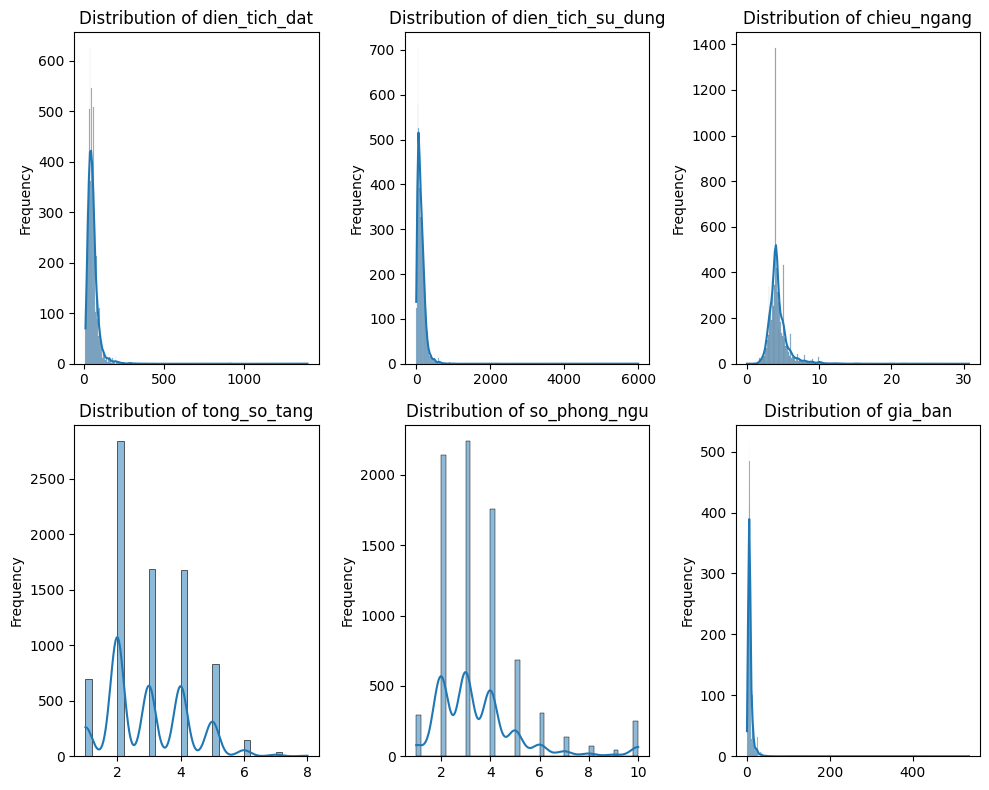

In [28]:
visualize_skewness_pandas(df2)

**Kiểm tra outlier của dữ liệu**

In [29]:
def visualize_outliers_pandas(df):

    # Xác định các cột số (numeric)
    numeric_cols = df.select_dtypes(include=['number']).columns.tolist()

    # Tự động tính toán lưới biểu đồ (layout)
    num_plots = len(numeric_cols)
    num_cols_grid = 3 # Số cột biểu đồ mỗi hàng
    num_rows_grid = math.ceil(num_plots / num_cols_grid)

    # Vẽ biểu đồ
    plt.figure(figsize=(10, 8))

    for i, column in enumerate(numeric_cols):
        plt.subplot(num_rows_grid, num_cols_grid, i + 1)

        # Vẽ Boxplot
        sns.boxplot(y=df[column])

        plt.title(f'Box Plot of {column}', fontsize=12)
        plt.ylabel('')

    # Hiển thị
    plt.tight_layout()
    plt.show()

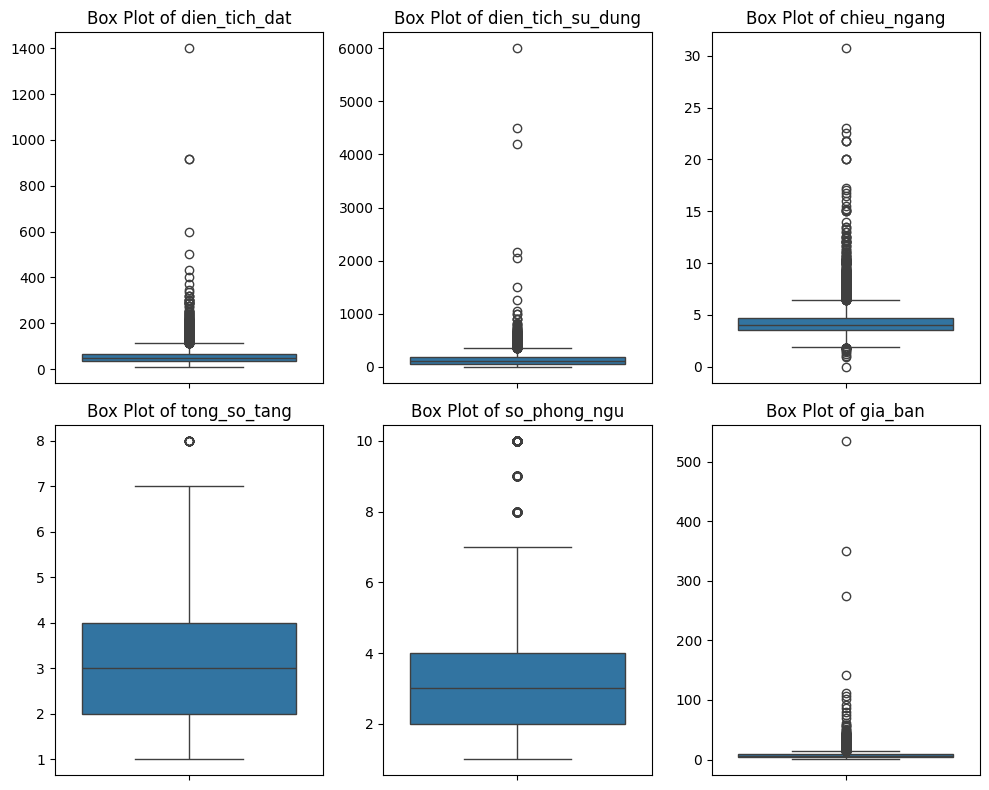

In [30]:
visualize_outliers_pandas(df2)

**Xử lý outlier**

In [31]:
def trim_outliers(df, columns, lower_percentile=0.004, upper_percentile=0.996):
    """
    Xử lý outlier bằng phương pháp Trimming (Loại bỏ dòng) sử dụng Pandas.
    - columns: Danh sách các cột cần xử lý
    - lower_percentile: Ngưỡng dưới (0.0 đến 1.0)
    - upper_percentile: Ngưỡng trên (0.0 đến 1.0)
    """
    df_initial_count = len(df)

    # Tạo một bản sao để tránh SettingWithCopyWarning
    df_trimmed = df.copy()

    for col_name in columns:
        if col_name not in df_trimmed.columns:
            print(f"Warning: Column '{col_name}' not found in DataFrame. Skipping.")
            continue

        # Ensure the column is numeric before calculating quantiles
        if df_trimmed[col_name].dtype == 'object':
            df_trimmed[col_name] = pd.to_numeric(df_trimmed[col_name], errors='coerce')

        # Drop rows where the current column is NaN, as quantiles cannot be calculated reliably
        df_trimmed_for_quantile = df_trimmed.dropna(subset=[col_name])

        if len(df_trimmed_for_quantile) == 0:
            print(f"Warning: Column '{col_name}' became entirely NaN after numeric conversion. Cannot calculate quantiles.")
            continue

        # Tính toán giá trị tại các ngưỡng bách phân vị
        lower_limit = df_trimmed_for_quantile[col_name].quantile(lower_percentile)
        upper_limit = df_trimmed_for_quantile[col_name].quantile(upper_percentile)

        if pd.isna(lower_limit) or pd.isna(upper_limit):
            print(f"Warning: Quantile limits for '{col_name}' are NaN [{lower_limit} - {upper_limit}]. Skipping trimming for this column.")
            continue

        # Xác định các dòng là outlier để thống kê
        outliers = df_trimmed[(df_trimmed[col_name] < lower_limit) |
                              (df_trimmed[col_name] > upper_limit)]

        outlier_count = len(outliers)
        per_cent = (outlier_count / df_initial_count) * 100

        print(f"Cột {col_name}: Ngưỡng lọc [{lower_limit:.4f} - {upper_limit:.4f}]")
        print(f"Tỉ lệ loại bỏ: {per_cent:.4f}%")

        # Loại bỏ (Filter) các dòng vượt quá ngưỡng
        df_trimmed = df_trimmed[(df_trimmed[col_name] >= lower_limit) &
                                (df_trimmed[col_name] <= upper_limit)]

    print(f"Tổng số dòng sau khi lọc: {len(df_trimmed)} (Giảm {df_initial_count - len(df_trimmed)} dòng)")

    return df_trimmed

In [32]:
lower_percentile = 0.004
upper_percentile = 0.996
cols_to_fix = ["chieu_ngang", "dien_tich_su_dung"]
df2 = trim_outliers(df2, cols_to_fix, lower_percentile, upper_percentile)

Cột chieu_ngang: Ngưỡng lọc [1.8439 - 12.1299]
Tỉ lệ loại bỏ: 0.5048%
Cột dien_tich_su_dung: Ngưỡng lọc [5.9817 - 632.6406]
Tỉ lệ loại bỏ: 0.7572%
Tổng số dòng sau khi lọc: 7824 (Giảm 100 dòng)


**Export dữ liệu final cho clustering**

In [33]:
clean_data_without_outliers_with_skewness = df2.to_csv(
    'clustering_data.csv', 
    index=False, 
    encoding='utf-8-sig'
)

#### **PCA**

In [34]:
num_cols = origin_numerical_cols

selector = VarianceThreshold(threshold=0.01)
selector.fit(df[num_cols])

selected_cols = df[num_cols].columns[selector.get_support()].tolist()

print(f"Giữ lại {len(selected_cols)}/{len(num_cols)} features: {selected_cols}")

Giữ lại 6/6 features: ['dien_tich_dat', 'dien_tich_su_dung', 'chieu_ngang', 'tong_so_tang', 'so_phong_ngu', 'gia_ban']


**Trước khi chạy K-Means cần xử lý đặc trưng (Feature Engineering),** K-Means dựa trên khoảng cách Euclidean, nên ta cần
- VectorAssembler: Gộp các cột thành một vector.
- StandardScaler: Đưa các giá trị (tỷ đồng, $m^2$, số phòng) về cùng một thang đo để tránh biến có giá trị lớn áp đảo.

In [35]:
def vectorize_and_scale(df, numerical_cols):
    # Lấy dữ liệu số
    X = df[numerical_cols]

    # Scale bằng RobustScaler
    scaler = RobustScaler(
        with_centering=True,
        with_scaling=True,
        quantile_range=(25.0, 75.0)  # tương đương lower=0.25, upper=0.75
    )

    X_scaled = scaler.fit_transform(X)

    # Gán lại vào DataFrame
    scaled_cols = [f"{col}_scaled" for col in numerical_cols]
    df_scaled = pd.DataFrame(X_scaled, columns=scaled_cols, index=df.index)

    # Gộp với DataFrame gốc
    vectorized_df = pd.concat([df, df_scaled], axis=1)

    return vectorized_df

In [36]:
def pca_dimension_reducing(df, numerical_cols):
    # Scale dữ liệu
    df_scaled = vectorize_and_scale(df, numerical_cols)
    X_scaled = df_scaled[[f"{col}_scaled" for col in numerical_cols]].values

    # PCA
    k = min(3, len(numerical_cols))
    pca = PCA(n_components=k)
    X_pca = pca.fit_transform(X_scaled)

    # Variance explained
    explained = pca.explained_variance_ratio_
    cumvar = explained.cumsum()
    k_95 = int((cumvar < 0.95).sum()) + 1

    print(f"Cần {k_95} PC để giữ 95% variance")
    print(f"Top PC variance: {[f'{v:.3f}' for v in explained[:5]]}")

    # Loading matrix
    loading_matrix = pca.components_.T  # shape: (n_features, k)

    # Đặt tên PC
    def make_pc_name(pc_idx, loadings_1d, feature_names, top_n=3):
        abs_load = np.abs(loadings_1d)
        top_idx = np.argsort(abs_load)[::-1][:top_n]
        top_names = [feature_names[i] for i in top_idx]
        return f"PC{pc_idx + 1}({','.join(top_names)})"

    pc_col_names = [
        make_pc_name(i, loading_matrix[:, i], numerical_cols, top_n=3)
        for i in range(k)
    ]

    print("Tên cột PC:", pc_col_names)

    # Tạo DataFrame PCA
    df_pca = df.copy()

    for i, col_name in enumerate(pc_col_names):
        df_pca[col_name] = X_pca[:, i]

    return df_pca

In [37]:
def execute_kmeans(df, k, pca_cols):
    """
    df: DataFrame chứa các cột PCA (ví dụ: PC1, PC2, PC3)
    pca_cols: list tên các cột PCA
    """

    # Lấy dữ liệu =====
    X = df[pca_cols].values

    # KMeans
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        init="k-means++",   # tương đương k-means||
        max_iter=100,
        tol=1e-6,
        n_init=10           # sklearn mặc định (quan trọng)
    )

    model = kmeans.fit(X)

    # Dự đoán cluster
    df_result = df.copy()
    df_result["prediction"] = model.labels_

    return model, df_result

**Hàm kích hoạt pipeline, chọn K tối ưu và trả kết quả silhouette, wcss**

In [38]:
def find_optimal_k_and_export_results(df, max_k, numerical_cols):

    silhouette_scores = []
    wcss_list = []
    result_kmeans = {}

    # PCA
    df_pca = pca_dimension_reducing(df, numerical_cols)

    # Lấy các cột PCA
    pca_cols = [col for col in df_pca.columns if col.startswith("PC")]
    X = df_pca[pca_cols].values

    # Loop K
    for k in range(2, max_k + 1):

        # Train KMeans
        model, predictions = execute_kmeans(df_pca, k, pca_cols)

        labels = predictions["prediction"].values

        # Silhouette Score
        silhouette = silhouette_score(X, labels)
        silhouette_scores.append((k, silhouette))

        # WCSS (inertia)
        wcss = model.inertia_
        wcss_list.append((k, wcss))

        print(f"K={k}: Silhouette={silhouette:.4f}, WCSS={wcss:.2f}")

        # Lưu kết quả
        result_kmeans[k] = {
            "model": model,
            "predictions": predictions,
            "silhouette": silhouette,
            "wcss": wcss
        }

    return silhouette_scores, wcss_list, result_kmeans

In [39]:
numerical_cols = ["dien_tich_dat", "dien_tich_su_dung", "chieu_ngang", "tong_so_tang", "so_phong_ngu", "gia_ban"]

**Áp dụng hàm và trả về kết quả khi chạy đến max_K = 10**

In [40]:
# Áp dụng pipeline và trả về kết quả (chọn max_k = 10: K-Means khởi chạy 10 vòng lặp để tìm K tối ưu)
max_k = 10
silhouette_scores, wcss_list, result_kmeans = find_optimal_k_and_export_results(df2, max_k, numerical_cols)

# Lấy danh sách k và wcsse
k_elbow_values = [x[0] for x in wcss_list]
wcss_values = [x[1] for x in wcss_list]

# Tìm K có Silhouette cao nhất
best_silhouette_tuple = builtins.max(silhouette_scores, key=lambda x: x[1])
best_k_for_silhouette = best_silhouette_tuple[0]
max_silhouette_score_value = best_silhouette_tuple[1]


Cần 4 PC để giữ 95% variance
Top PC variance: ['0.636', '0.153', '0.099']
Tên cột PC: ['PC1(gia_ban,dien_tich_dat,chieu_ngang)', 'PC2(chieu_ngang,so_phong_ngu,tong_so_tang)', 'PC3(gia_ban,so_phong_ngu,chieu_ngang)']
K=2: Silhouette=0.5343, WCSS=24258.96
K=3: Silhouette=0.3750, WCSS=17799.77
K=4: Silhouette=0.3251, WCSS=14969.27
K=5: Silhouette=0.3367, WCSS=12677.72
K=6: Silhouette=0.2875, WCSS=11362.55
K=7: Silhouette=0.2897, WCSS=10242.49
K=8: Silhouette=0.2941, WCSS=9472.29
K=9: Silhouette=0.2798, WCSS=8836.99
K=10: Silhouette=0.2764, WCSS=8175.70


**Trực quan kết quả**

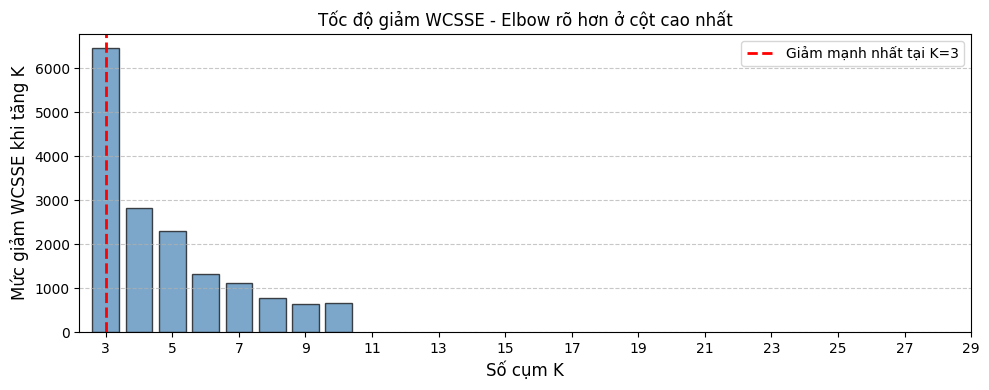

K có mức giảm WCSSE lớn nhất: K = 3
Gợi ý: Elbow nằm ở K = 3 hoặc K = 4
----------------------------------------------------------------------------------------------------



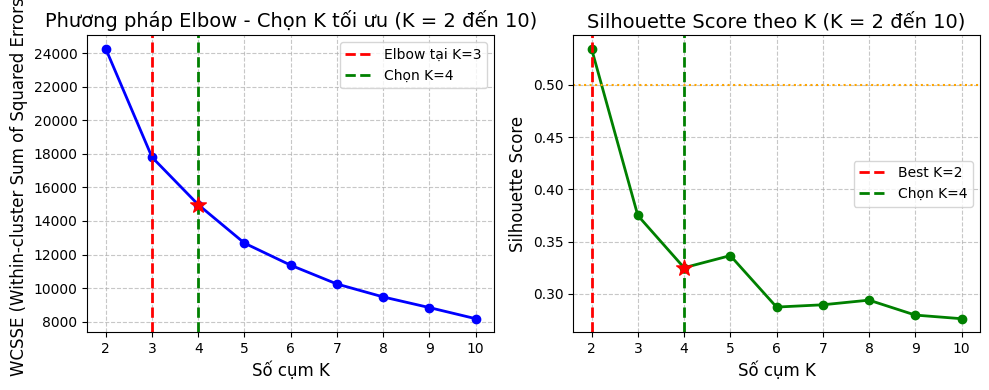

In [41]:
elbow_k = 4  # Điểm K tự chọn

# Tính tốc độ giảm WCSSE (chênh lệch giữa các K liên tiếp)
wcsse_diff = []

for i in range(1, len(wcss_values)):
    diff = wcss_values[i-1] - wcss_values[i]  # Mức giảm khi tăng K thêm 1
    wcsse_diff.append(diff)

k_diff = k_elbow_values[1:]  # K từ 3 trở đi (vì diff bắt đầu từ K=3)

# Vẽ biểu đồ
plt.figure(figsize=(10, 4))
plt.bar(k_diff, wcsse_diff, color='steelblue', edgecolor='black', alpha=0.7)
plt.xlabel('Số cụm K', fontsize=12)
plt.ylabel('Mức giảm WCSSE khi tăng K', fontsize=12)
plt.title('Tốc độ giảm WCSSE - Elbow rõ hơn ở cột cao nhất', fontsize=12)
plt.xticks(range(3, 31, 2))
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Đánh dấu điểm giảm mạnh nhất
max_diff_k = k_diff[wcsse_diff.index(builtins.max(wcsse_diff))]
plt.axvline(x=max_diff_k, color='red', linestyle='--', linewidth=2,
            label=f'Giảm mạnh nhất tại K={max_diff_k}')
plt.legend()
plt.tight_layout()
plt.show()

print(f"K có mức giảm WCSSE lớn nhất: K = {max_diff_k}")
print(f"Gợi ý: Elbow nằm ở K = {max_diff_k} hoặc K = {max_diff_k + 1}")
print('-'*100 + '\n')

# Tạo figure với 2 subplot cạnh nhau
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# ========== Biểu đồ 1: Elbow Method (WSSSE) ==========
axes[0].plot(k_elbow_values, wcss_values, 'bo-', linewidth=2, markersize=6)
axes[0].set_xlabel('Số cụm K', fontsize=12)
axes[0].set_ylabel('WCSSE (Within-cluster Sum of Squared Errors)', fontsize=12)
axes[0].set_title(f'Phương pháp Elbow - Chọn K tối ưu (K = 2 đến {max_k})', fontsize=14)
axes[0].set_xticks(range(2, 31))
axes[0].grid(True, linestyle='--', alpha=0.7)

# Đánh dấu điểm khuỷu tay
elbow_k_optimal = max_diff_k

axes[0].axvline(x=elbow_k_optimal, color='red', linestyle='--', linewidth=2, label=f'Elbow tại K={elbow_k_optimal}')
axes[0].axvline(x=elbow_k, color='green', linestyle='--', linewidth=2, label=f'Chọn K={elbow_k}')

axes[0].scatter([elbow_k], [wcss_values[elbow_k-2]], color='red', s=140, zorder=5, marker='*')
axes[0].legend(fontsize=10)

# ========== Biểu đồ 2: Silhouette Score ==========
k_sil_values = [x[0] for x in silhouette_scores] # K values for silhouette
sil_scores_values = [x[1] for x in silhouette_scores] # Silhouette scores

axes[1].plot(k_sil_values, sil_scores_values, 'go-', linewidth=2, markersize=6)
axes[1].set_xlabel('Số cụm K', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title(f'Silhouette Score theo K (K = 2 đến {max_k})', fontsize=14)
axes[1].set_xticks(range(2, 31))
axes[1].grid(True, linestyle='--', alpha=0.7)

# Đánh dấu điểm có silhouette cao nhất
axes[1].axvline(x=best_k_for_silhouette, color='red', linestyle='--', linewidth=2, label=f'Best K={best_k_for_silhouette}')
axes[1].axvline(x=elbow_k, color='green', linestyle='--', linewidth=2, label=f'Chọn K={elbow_k}')
axes[1].scatter([elbow_k], [sil_scores_values[elbow_k-2]], color='red', s=140, zorder=5, marker='*')
axes[1].legend(fontsize=10)

# Thêm đường tham chiếu Silhouette = 0.5 (ngưỡng "chấp nhận được")
axes[1].axhline(y=0.5, color='orange', linestyle=':', linewidth=1.5, label='Ngưỡng 0.5')

plt.tight_layout()
plt.savefig('elbow_silhouette_k30.png', dpi=150, bbox_inches='tight')  # Lưu hình
plt.show()

**Chuẩn bị dữ liệu cho trực quan hóa biểu đồ phân cụm**

In [42]:
predictions = result_kmeans[elbow_k]["predictions"]

print(predictions.head())

                                                                  tieu_de  \
0                                         Nhà hẻm cách đường mặt tiền 20m   
1                                            BÁN NHÀ 2 TẦNG HẺM BẠCH ĐẰNG   
2                                                             Bán nhà 50m   
3  NHÀ 5LẦU MẶT TIỀN ĐƯỜNG NGUYỄN VĂN THƯƠNG,P25,BT.Đoạn KD sầm uất, 9pn.   
4          Hẻm 6m ô tô ngủ trong nhà- 68m2 - KDC Sạch đẹp. NHỈNH 11 TỶ TL   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                         

In [43]:
df_clustered = predictions.copy()

pca_numerical_cols = [
    'x1_phan_khuc_gia_theo_ti_le_dt_dat_dt_su_dung',
    'x2_phan_khuc_gia_theo_ti_le_chieu_ngang_tong_so_tang',
    'x3_phan_khuc_gia_theo_ti_le_so_phong_ngu_tong_so_tang'
]

# Lấy các cột PCA hiện có
pca_cols = [col for col in df_clustered.columns if col.startswith("PC")]

# Rename PC → tên mới
rename_dict = dict(zip(pca_cols, pca_numerical_cols))
df_clustered = df_clustered.rename(columns=rename_dict)

df_clustered.head(1)

,tieu_de,mo_ta,dien_tich_dat,dien_tich_su_dung,chieu_ngang,tong_so_tang,so_phong_ngu,loai_hinh,giay_to_phap_ly,tinh_trang_noi_that,huong_cua_chinh,dac_diem,dia_chi_cu,dia_chi_moi,gia_ban,quan,x1_phan_khuc_gia_theo_ti_le_dt_dat_dt_su_dung,x2_phan_khuc_gia_theo_ti_le_chieu_ngang_tong_so_tang,x3_phan_khuc_gia_theo_ti_le_so_phong_ngu_tong_so_tang,prediction
0,Nhà hẻm cách đường mặt tiền 20m,"Nhà hẻm cách đường mặt tiền 20m\nNhà ở khu vực cao không ngập lụt, khu dân cư yên tĩnh,... \nGần trường học cán bộ TPHCM, siêu thị, chợ,.... \nGiá 2 tỷ 850 còn thương lượng\nSổ hồng chính chủ \nLH ***",18.0,18.0,3.0,1.0,2.0,nha_ngo_hem,da_co_so,chua_xac_dinh,bac,hien_trang_khac,phuong_12_quan_binh_thanh,phuong_binh_thanh,2.85,quan_binh_thanh,-2.48641,-0.066155,0.513957,1


**Tìm tâm cụm**

In [44]:
centers = result_kmeans[elbow_k]['model'].cluster_centers_
centers_df = pd.DataFrame(centers)
centers_df = centers_df.rename(columns={0: "x1_center", 1: "x2_center", 2: "x3_center"})
print("Clustering Centers: ")
centers_df.head()

Clustering Centers: 


,x1_center,x2_center,x3_center
0,0.282461,-0.088629,-0.250102
1,-1.432095,-0.041714,0.230540
2,6.995003,-0.542330,1.135499
3,2.575926,0.580469,-0.268876


**Vẽ biểu đồ trực quan hóa kết quả**

**2D**

In [45]:
def visualize_2D_clustering_scatter(df, prediction_col, selected_dimensions, centers_df_pairing, labels):
    #
    pdf_clustered = df.copy()

    # Khởi tạo biểu đồ
    fig, ax = plt.subplots(figsize=(10, 7))

    # Thiết lập bảng màu tự động dựa trên số lượng cụm
    clusters = sorted(pdf_clustered[prediction_col].unique())
    colors = plt.cm.get_cmap('viridis', len(clusters))
    for i, cluster in enumerate(clusters):
        # Lọc dữ liệu cho từng cụm
        cluster_data = pdf_clustered[pdf_clustered[prediction_col] == cluster]

        # Kiểm tra nếu cụm có dữ liệu mới vẽ
        if not cluster_data.empty:
            ax.scatter(
                cluster_data[selected_dimensions[0]],
                cluster_data[selected_dimensions[1]],        # Trục Y dùng Giá bán để thấy insight rõ hơn
                label=f'Cụm {cluster}',
                alpha=0.6,
                edgecolors='w',
                s=80 # Kích thước điểm
            )

        # Vẽ center lên plot
        sns.scatterplot(data=centers_df,
                        x=centers_df_pairing[0],
                        y=centers_df_pairing[1],
                        color="black",
                        marker="x",
                        linewidths=4,
                        s=300)

    # Trang trí biểu đồ
    ax.set_xlabel(labels[0])
    ax.set_ylabel(labels[1])
    ax.set_title(labels[2])
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.5)

    plt.show()

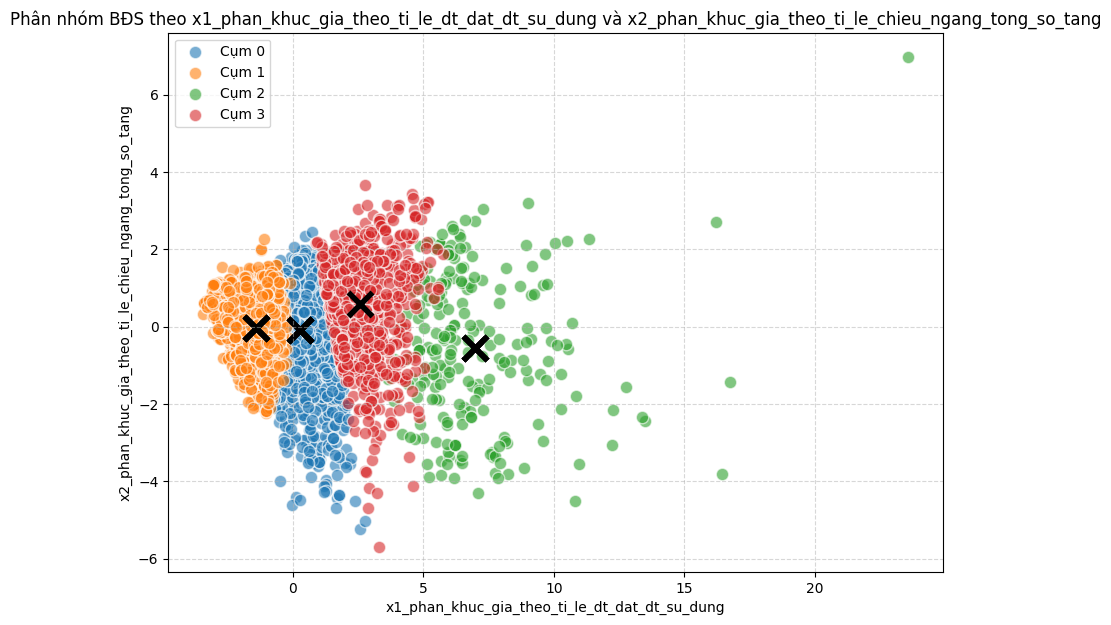

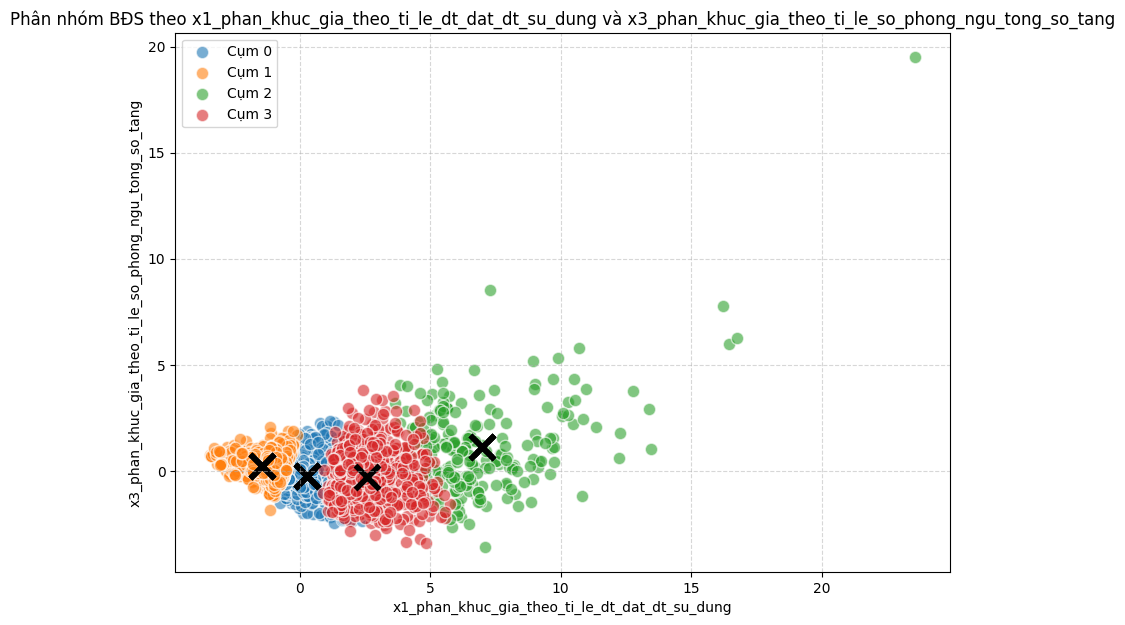

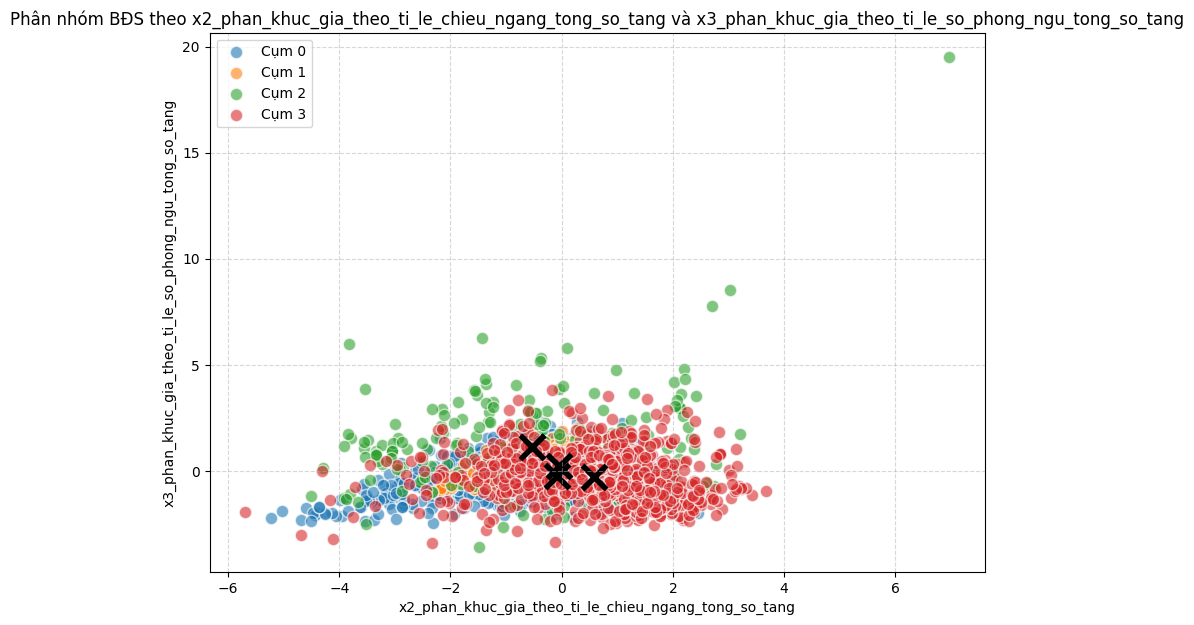

In [46]:
prediction_col = 'prediction'
mapping = dict(zip(pca_numerical_cols, centers_df.columns))
numerical_pairs = list(combinations(pca_numerical_cols, 2))
centers_pairs = [
    [mapping[col1], mapping[col2]]
    for col1, col2 in numerical_pairs
]

for (dim1, dim2), (c1, c2) in zip(numerical_pairs, centers_pairs):
    #
    labels = [
        dim1,
        dim2,
        f'Phân nhóm BĐS theo {dim1} và {dim2}'
    ]
    #
    visualize_2D_clustering_scatter(
        df_clustered,
        prediction_col,
        selected_dimensions=[dim1, dim2],
        centers_df_pairing=[c1, c2],
        labels=labels
    )

## **Với K = 4 sẽ phân cụm thành 4 phân khúc nhà ở: Bình dân - cụm 1, sơ cấp - cụm 0, trung cấp - cụm 3, cao cấp - cụm 2**

In [47]:
def visualize_clustering_boxplots(df, prediction_col, features_to_plot):
    pdf_clustered = df.copy()

    clusters = sorted(pdf_clustered[prediction_col].unique())
    num_clusters = len(clusters)
    num_features = len(features_to_plot)

    # Dynamically create subplots
    num_cols_per_row = min(num_features, 3) # Max 3 columns per row
    num_rows = math.ceil(num_features / num_cols_per_row)
    fig, axes = plt.subplots(num_rows, num_cols_per_row, figsize=(num_cols_per_row * 5, num_rows * 4))
    axes = axes.flatten() if num_rows > 1 or num_cols_per_row > 1 else [axes] # Ensure axes is iterable

    # Set up a colormap for clusters
    # Ensure num_clusters is at least 1 for cmap indexing
    cluster_colors_list = [plt.cm.get_cmap('viridis', max(1, num_clusters))(c_idx / max(1, num_clusters - 1)) for c_idx in range(num_clusters)]

    for idx, feature in enumerate(features_to_plot):
        if idx < len(axes):
            sns.boxplot(
                data=pdf_clustered,
                x=prediction_col,
                y=feature,
                ax=axes[idx],
                palette=cluster_colors_list
            )
            axes[idx].set_title(f'Distribution of x{idx+1} by Cluster', fontsize=12)
            axes[idx].set_xlabel('Cluster')
            axes[idx].set_ylabel(feature)
            axes[idx].grid(True, linestyle='--', alpha=0.6)
        else:
            print(f"Warning: Not enough subplots for feature {feature}. Skipping.")

    # Remove any unused subplots
    for i in range(num_features, len(axes)):
        fig.delaxes(axes[i])

    plt.tight_layout()
    plt.show()

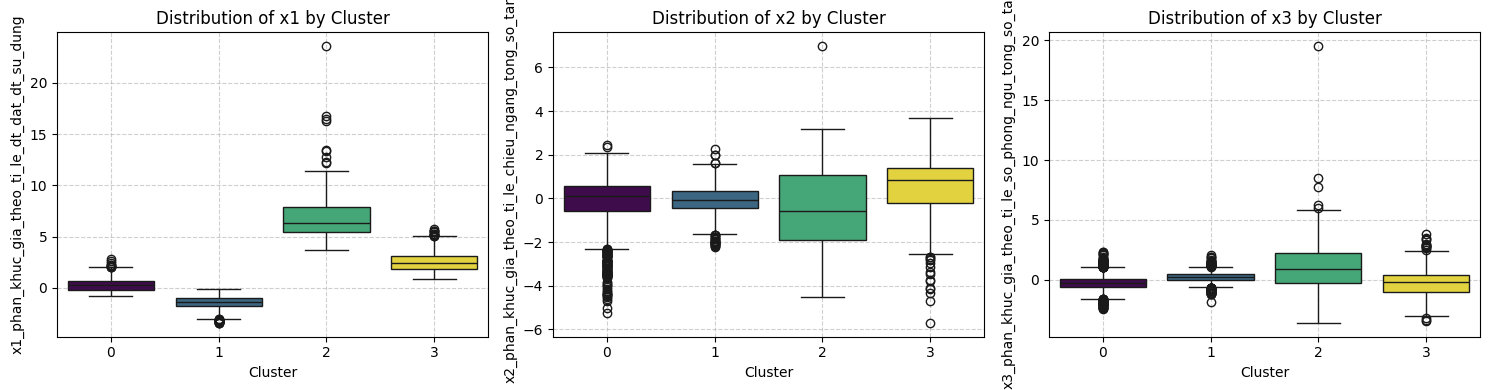

In [48]:
visualize_clustering_boxplots(df_clustered, prediction_col, pca_numerical_cols)

In [49]:
def visualize_2D_clustering_heatmap(df, prediction_col, features_to_plot):
    # Calculate the mean of features_to_plot for each cluster
    cluster_means = df.groupby(prediction_col)[features_to_plot].mean()

    plt.figure(figsize=(10, 6))
    sns.heatmap(cluster_means.T, annot=True, cmap='YlGnBu', fmt='.3f',
                yticklabels=features_to_plot,
                xticklabels=[f'Cụm {i}' for i in cluster_means.index])
    plt.title('Trung bình các thành phần PCA theo cụm', fontsize=14)
    plt.ylabel('Thành phần PCA')
    plt.xlabel('Cụm')
    plt.show()

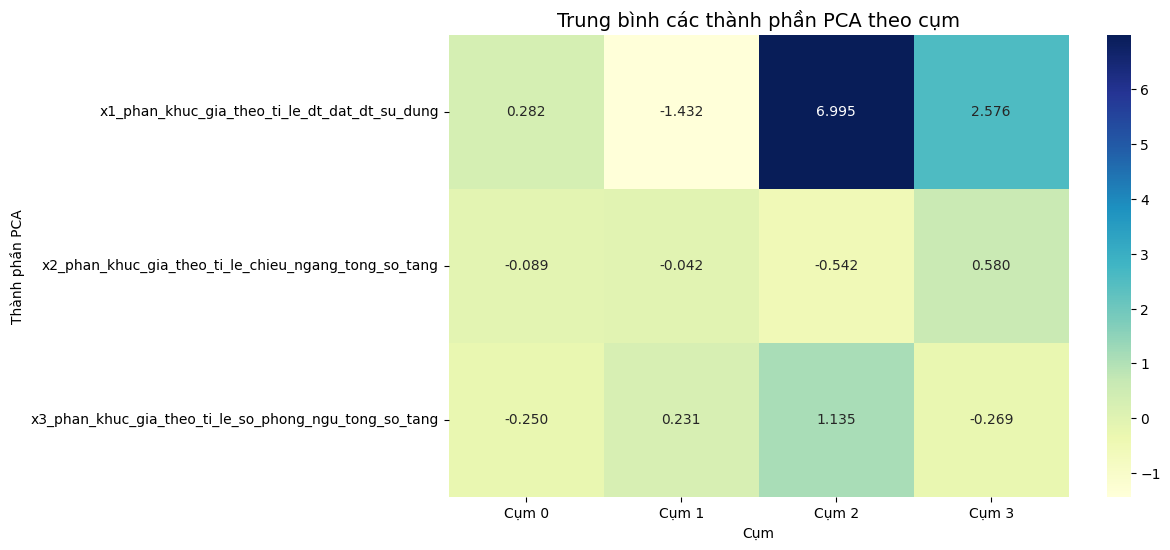

In [50]:
visualize_2D_clustering_heatmap(df_clustered, prediction_col, pca_numerical_cols)

**3D**

In [51]:
def visualize_3D_clustering(df, prediction_col, selected_dimensions, model):
    #
    pdf_clustered = df.copy()

    fig = plt.figure(figsize=(11, 11))
    ax = fig.add_subplot(111, projection='3d')
    colors = ['red', 'blue', 'green', 'orange', 'purple']

    # Vẽ các điểm
    for cluster in pdf_clustered[prediction_col].unique():
        cluster_data = pdf_clustered[pdf_clustered[prediction_col] == cluster]
        ax.scatter(
            cluster_data[selected_dimensions[0]],
            cluster_data[selected_dimensions[1]],
            cluster_data[selected_dimensions[2]],
            c=colors[cluster % len(colors)],
            label=f'Cụm {cluster}',
            alpha=0.6,
            s=6
        )

    # Trang trí
    ax.set_xlabel(selected_dimensions[0], fontsize=12)
    ax.set_ylabel(selected_dimensions[1], fontsize=12)
    ax.set_zlabel(selected_dimensions[2], fontsize=12)

    # Chỉnh góc nhìn để thấy rõ nhãn Z
    # ax.view_init(elev=20, azim=45)

    ax.set_title(f'Phân cụm K-Means (K={elbow_k})', fontsize=14)
    ax.legend(loc='upper left', bbox_to_anchor=(0.8, 0.9), fontsize=12)
    plt.tight_layout()
    plt.show()



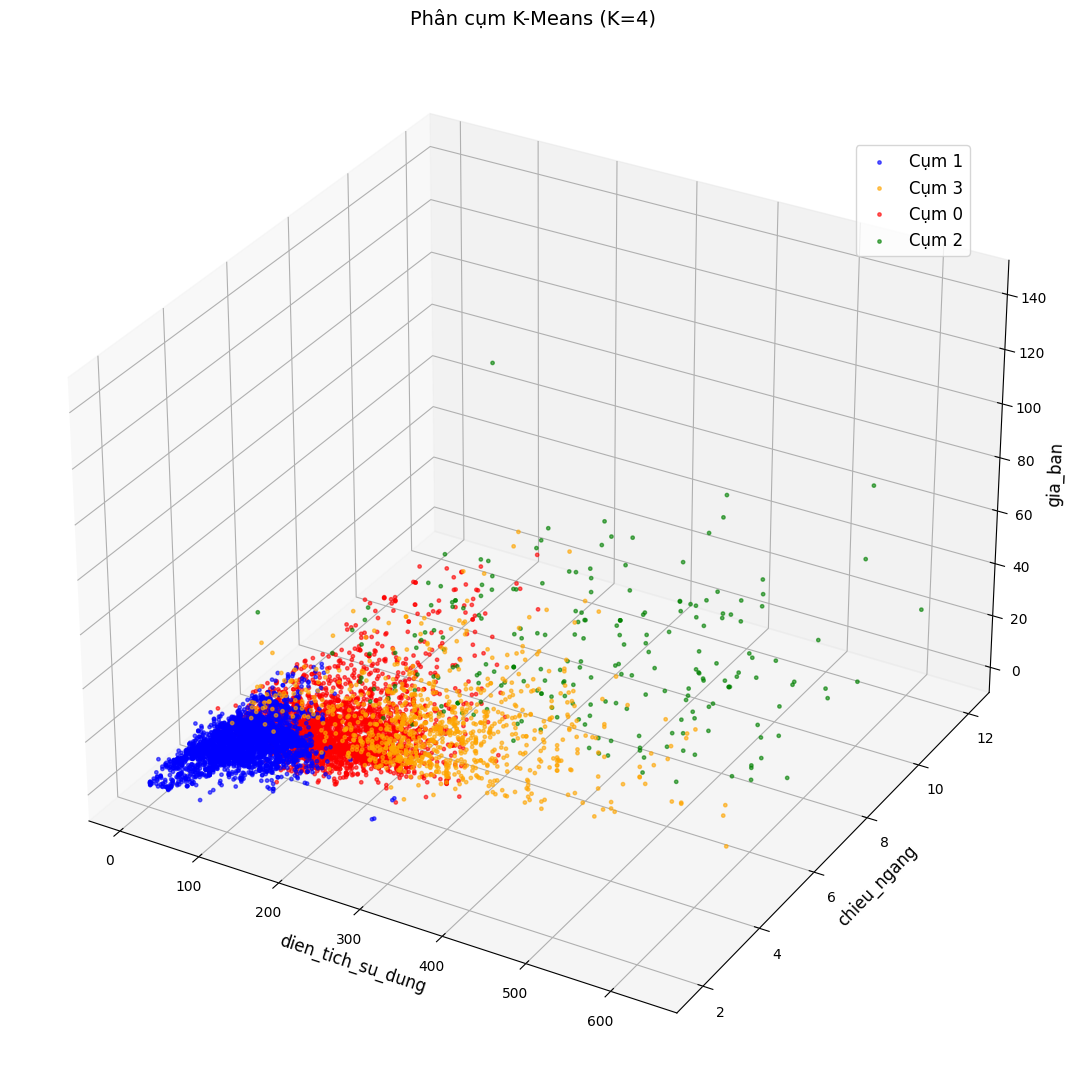

In [52]:
prediction_col = 'prediction'
model = result_kmeans[elbow_k]["model"]
selected_dimensions = ['dien_tich_su_dung', 'chieu_ngang', 'gia_ban']
visualize_3D_clustering(df_clustered, prediction_col, selected_dimensions, model)

**Tách riêng các cluster để phân tích insight**

In [53]:
def separated_clustered_df(df, prediction_col):
    # Lấy các cluster unique
    clusters = sorted(df[prediction_col].dropna().unique())

    sc_df_list = []

    for cluster_id in clusters:
        # Lọc dữ liệu theo từng cluster
        cluster_data = df[df[prediction_col] == cluster_id]

        sc_df_list.append(cluster_data)

    return sc_df_list

In [54]:
df_clustering = separated_clustered_df(df_clustered, prediction_col)
pc_df_1 = df_clustering[0]
pc_df_1.head(1)

,tieu_de,mo_ta,dien_tich_dat,dien_tich_su_dung,chieu_ngang,tong_so_tang,so_phong_ngu,loai_hinh,giay_to_phap_ly,tinh_trang_noi_that,huong_cua_chinh,dac_diem,dia_chi_cu,dia_chi_moi,gia_ban,quan,x1_phan_khuc_gia_theo_ti_le_dt_dat_dt_su_dung,x2_phan_khuc_gia_theo_ti_le_chieu_ngang_tong_so_tang,x3_phan_khuc_gia_theo_ti_le_so_phong_ngu_tong_so_tang,prediction
2,Bán nhà 50m,"👉Nhà 3 TẦNG -HẺM XE HƠI - gía:11,2 TỶ \n👉Có giá tốt cho khách đầu năm \n🏡 Vị trí đắc địa: Bình Thạnh - Khu dân trí, hiếm nhà bán.\n✅Hẻm trước nhà 8m xe tải tránh nhau. Đi về Bình Thạnh và Quận 1, Phú Nhuận, Sân Bay rất thuận tiện.\n✅ Gần 10 trường Đại học lớn. Đh Ngoại Thường. Đh Giao thông. Đh Hutech. Đh Quốc tế Hồng Bàng. Đh Văn Lang ... \n✅Xung quanh đầy đủ tiện ích: chợ, siêu thị Bách Hoá Xanh... trường học cấp 1.2.3 Đại Học, Ngân hàng…full tiện ích.\n-----------,🏆----------\n🇻🇳Thông tin căn nhà:\n\n✅Diện tích sử dụng 3 tầng : hơn 59,4 m2\n✅Xây dựng trệt lửng 2 tầng lầu, hoàn công đầy đủ: Đầy đủ công năng gồm: phòng khách,phòng bếp,4 phòng ngủ. 4 vệ sinh. Ban công\n👉Giá:11,2 ti TL",59.4,59.4,5.256637,3.0,4.0,nha_ngo_hem,da_co_so,chua_xac_dinh,dong,hem_xe_hoi,phuong_26_quan_binh_thanh,phuong_binh_thanh,11.2,quan_binh_thanh,0.817013,-0.501658,0.235304,0


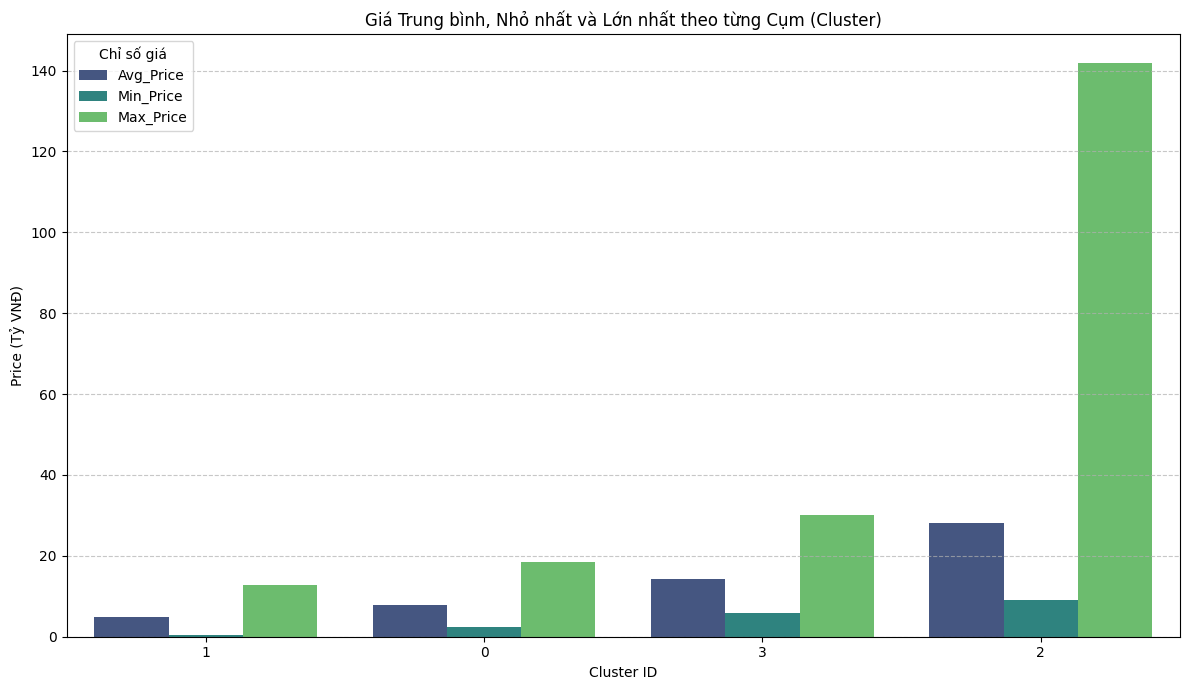

In [55]:
cluster_price_stats = predictions.groupby("prediction").agg(
    Avg_Price=('gia_ban', 'mean'),
    Min_Price=('gia_ban', 'min'),
    Max_Price=('gia_ban', 'max'),
    Count=('gia_ban', 'count') # Hoặc dùng cột 'id' nếu có: ('id', 'count')
).reset_index()

# Sắp xếp theo Avg_Price
cluster_price_stats = cluster_price_stats.sort_values("Avg_Price")

# Melt DataFrame sang dạng long format để vẽ biểu đồ với Seaborn
cluster_price_melted = cluster_price_stats.melt(
    id_vars=['prediction', 'Count'],
    value_vars=['Avg_Price', 'Min_Price', 'Max_Price'],
    var_name='Price_Metric',
    value_name='Price_Value'
)

order_by_avg_price = cluster_price_stats["prediction"].tolist()

# Vẽ biểu đồ
plt.figure(figsize=(12, 7))
sns.barplot(
    x='prediction', 
    y='Price_Value', 
    hue='Price_Metric', 
    data=cluster_price_melted, 
    order=order_by_avg_price,
    palette='viridis'
)

plt.xlabel('Cluster ID')
plt.ylabel('Price (Tỷ VNĐ)')
plt.title('Giá Trung bình, Nhỏ nhất và Lớn nhất theo từng Cụm (Cluster)')
plt.legend(title='Chỉ số giá')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

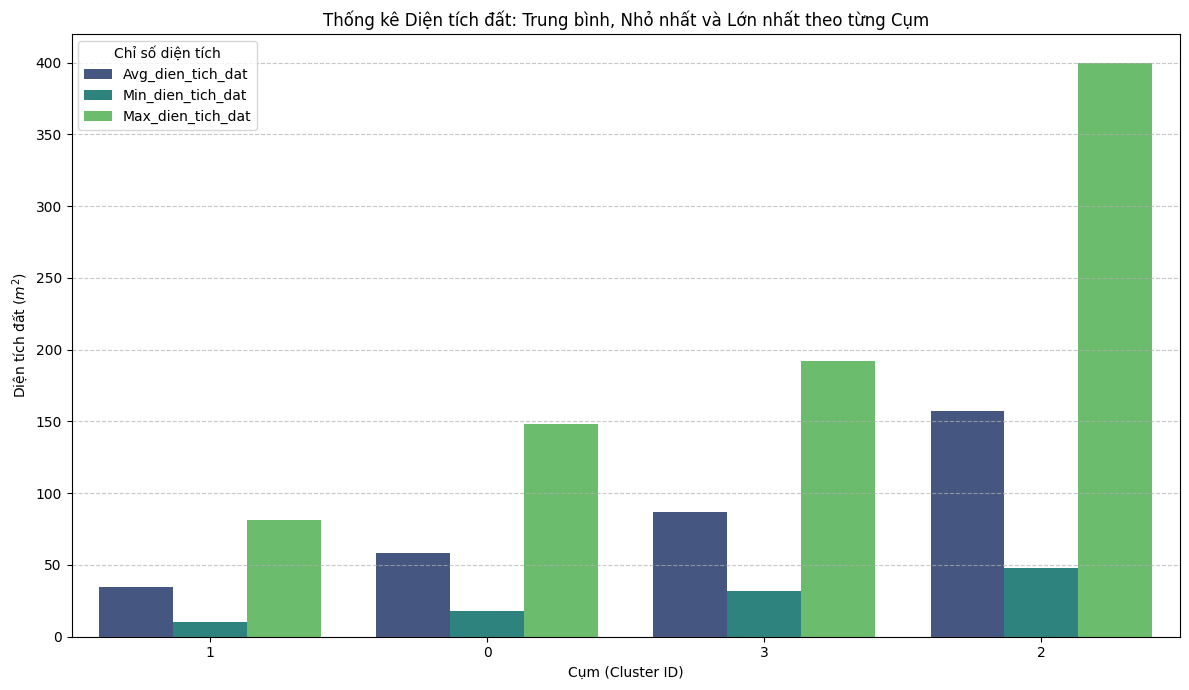

In [56]:
# Nhóm dữ liệu và tính toán thống kê diện tích bằng Pandas
cluster_dien_tich_dat_stats = predictions.groupby("prediction").agg(
    Avg_dien_tich_dat=('dien_tich_dat', 'mean'),
    Min_dien_tich_dat=('dien_tich_dat', 'min'),
    Max_dien_tich_dat=('dien_tich_dat', 'max'),
    Count=('gia_ban', 'count')
).reset_index()

# Sắp xếp theo Min_dien_tich_dat
cluster_dien_tich_dat_stats = cluster_dien_tich_dat_stats.sort_values("Min_dien_tich_dat")

# Melt DataFrame sang dạng long format để Seaborn có thể vẽ được
cluster_dien_tich_dat_melted = cluster_dien_tich_dat_stats.melt(
    id_vars=['prediction', 'Count'],
    value_vars=['Avg_dien_tich_dat', 'Min_dien_tich_dat', 'Max_dien_tich_dat'],
    var_name='dien_tich_dat_Metric',
    value_name='dien_tich_dat_Value'
)

order_by_min_dien_tich_dat = cluster_dien_tich_dat_stats["prediction"].tolist()

# Cấu hình và vẽ biểu đồ
plt.figure(figsize=(12, 7))
sns.barplot(
    x='prediction', 
    y='dien_tich_dat_Value', 
    hue='dien_tich_dat_Metric', 
    data=cluster_dien_tich_dat_melted, 
    order=order_by_min_dien_tich_dat,
    palette='viridis'
)

# Việt hóa các nhãn biểu đồ cho chuyên nghiệp
plt.xlabel('Cụm (Cluster ID)')
plt.ylabel('Diện tích đất ($m^2$)')
plt.title('Thống kê Diện tích đất: Trung bình, Nhỏ nhất và Lớn nhất theo từng Cụm')
plt.legend(title='Chỉ số diện tích')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

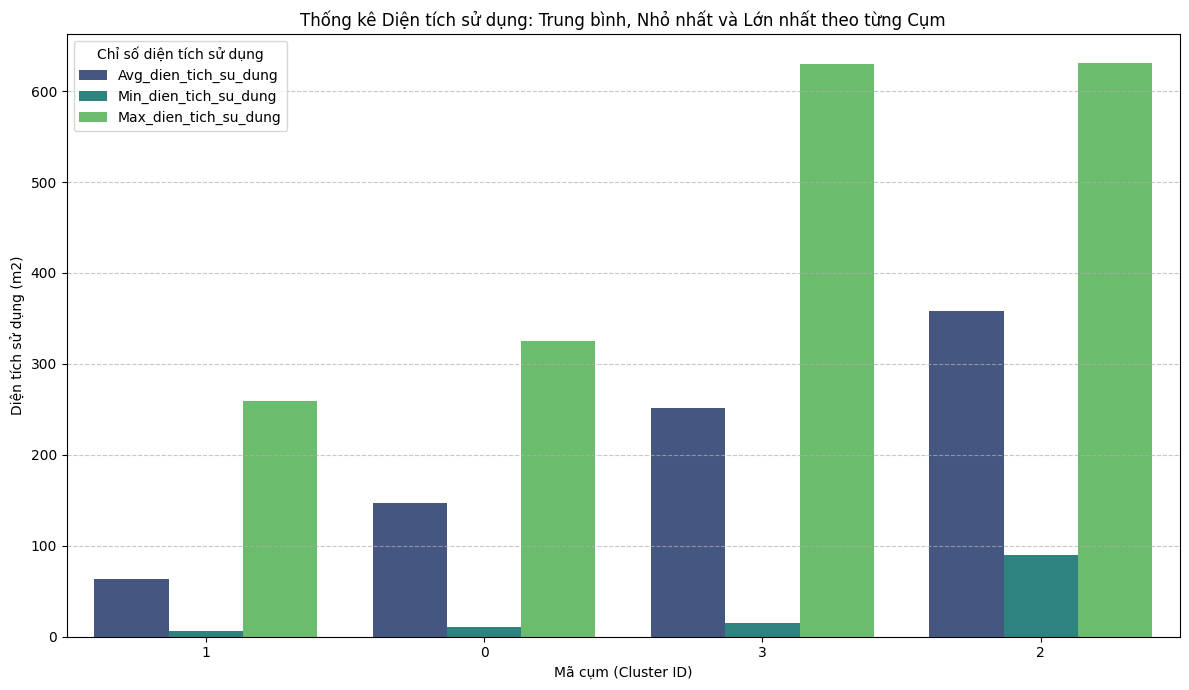

In [57]:
cluster_dien_tich_su_dung_stats = predictions.groupby("prediction").agg(
    Avg_dien_tich_su_dung=('dien_tich_su_dung', 'mean'),
    Min_dien_tich_su_dung=('dien_tich_su_dung', 'min'),
    Max_dien_tich_su_dung=('dien_tich_su_dung', 'max'),
    Count=('gia_ban', 'count')
).reset_index()

# Sắp xếp theo Min_dien_tich_su_dung
cluster_dien_tich_su_dung_stats = cluster_dien_tich_su_dung_stats.sort_values("Min_dien_tich_su_dung")

# Chuyển đổi DataFrame sang dạng long format (Melt) để vẽ biểu đồ
cluster_dien_tich_su_dung_melted = cluster_dien_tich_su_dung_stats.melt(
    id_vars=['prediction', 'Count'],
    value_vars=['Avg_dien_tich_su_dung', 'Min_dien_tich_su_dung', 'Max_dien_tich_su_dung'],
    var_name='dien_tich_su_dung_Metric',
    value_name='dien_tich_su_dung_Value'
)

order_by_min_dien_tich_su_dung = cluster_dien_tich_su_dung_stats["prediction"].tolist()

# Trực quan hóa dữ liệu
plt.figure(figsize=(12, 7))
sns.barplot(
    x='prediction', 
    y='dien_tich_su_dung_Value', 
    hue='dien_tich_su_dung_Metric', 
    data=cluster_dien_tich_su_dung_melted, 
    order=order_by_min_dien_tich_su_dung,
    palette='viridis'
)

# Tinh chỉnh các nhãn hiển thị
plt.xlabel('Mã cụm (Cluster ID)')
plt.ylabel('Diện tích sử dụng (m2)')
plt.title('Thống kê Diện tích sử dụng: Trung bình, Nhỏ nhất và Lớn nhất theo từng Cụm')
plt.legend(title='Chỉ số diện tích sử dụng')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

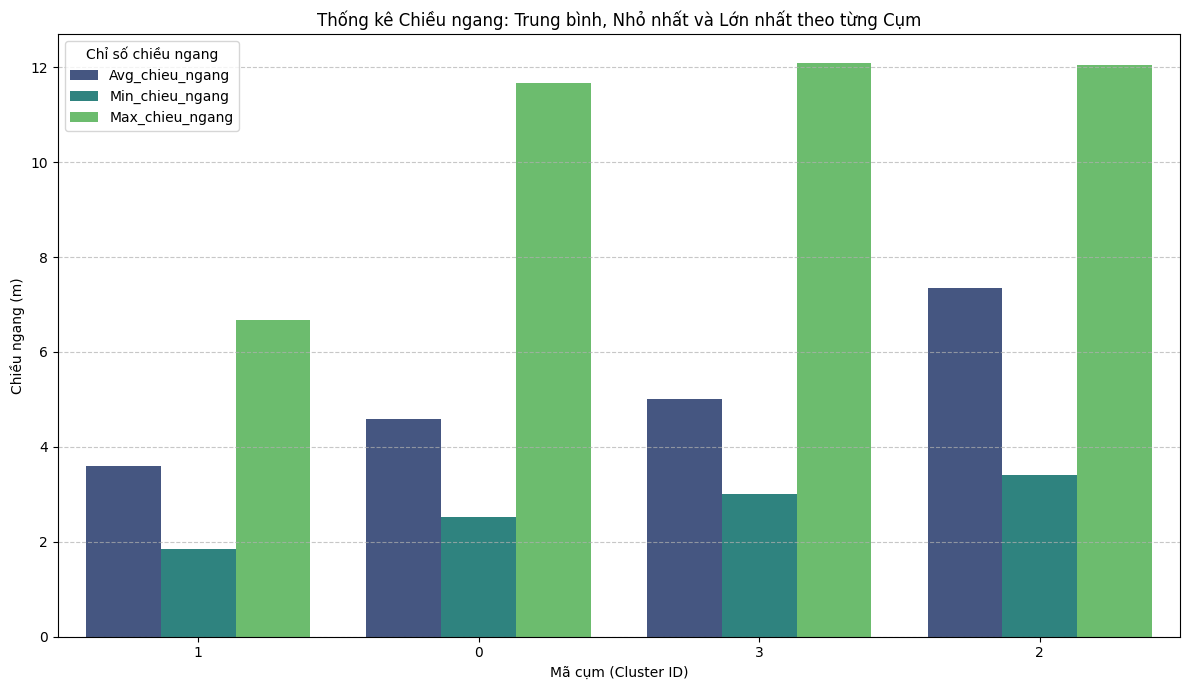

In [58]:
cluster_chieu_ngang_stats = predictions.groupby("prediction").agg(
    Avg_chieu_ngang=('chieu_ngang', 'mean'),
    Min_chieu_ngang=('chieu_ngang', 'min'),
    Max_chieu_ngang=('chieu_ngang', 'max'),
    Count=('gia_ban', 'count')
).reset_index()

# Sắp xếp theo Avg_chieu_ngang
cluster_chieu_ngang_stats = cluster_chieu_ngang_stats.sort_values("Avg_chieu_ngang")


# Chuyển đổi DataFrame sang dạng long format (Melt) để Seaborn vẽ barplot
cluster_chieu_ngang_melted = cluster_chieu_ngang_stats.melt(
    id_vars=['prediction', 'Count'],
    value_vars=['Avg_chieu_ngang', 'Min_chieu_ngang', 'Max_chieu_ngang'],
    var_name='chieu_ngang_Metric',
    value_name='chieu_ngang_Value'
)

order_by_avg_chieu_ngang = cluster_chieu_ngang_stats["prediction"].tolist()

# Trực quan hóa dữ liệu
plt.figure(figsize=(12, 7))
sns.barplot(
    x='prediction', 
    y='chieu_ngang_Value', 
    hue='chieu_ngang_Metric', 
    data=cluster_chieu_ngang_melted, 
    order=order_by_avg_chieu_ngang,
    palette='viridis'
)

# Tinh chỉnh các nhãn hiển thị cho dự án Quận 7
plt.xlabel('Mã cụm (Cluster ID)')
plt.ylabel('Chiều ngang (m)')
plt.title('Thống kê Chiều ngang: Trung bình, Nhỏ nhất và Lớn nhất theo từng Cụm')
plt.legend(title='Chỉ số chiều ngang')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

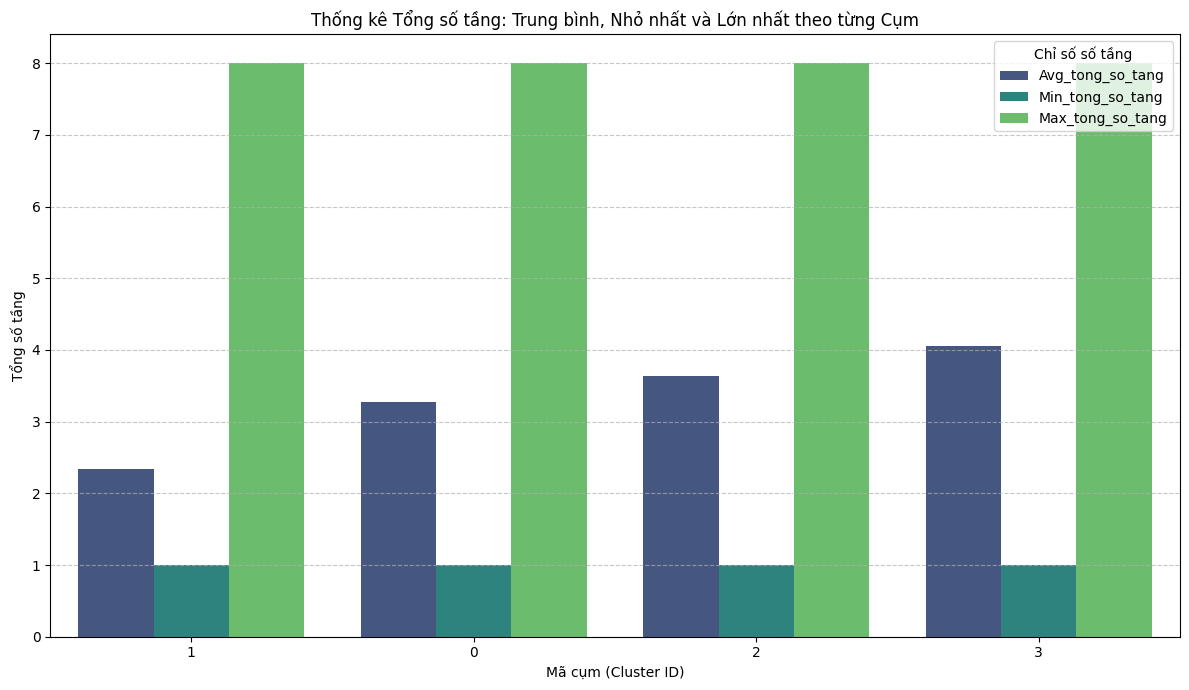

In [59]:
cluster_tong_so_tang_stats = predictions.groupby("prediction").agg(
    Avg_tong_so_tang=('tong_so_tang', 'mean'),
    Min_tong_so_tang=('tong_so_tang', 'min'),
    Max_tong_so_tang=('tong_so_tang', 'max'),
    Count=('gia_ban', 'count')
).reset_index()

# Sắp xếp theo Avg_tong_so_tang
cluster_tong_so_tang_stats = cluster_tong_so_tang_stats.sort_values("Avg_tong_so_tang")
order_by_avg_tong_so_tang = cluster_tong_so_tang_stats["prediction"].tolist()


# Chuyển đổi sang dạng long format (Melt) để vẽ biểu đồ
cluster_tong_so_tang_melted = cluster_tong_so_tang_stats.melt(
    id_vars=['prediction', 'Count'],
    value_vars=['Avg_tong_so_tang', 'Min_tong_so_tang', 'Max_tong_so_tang'],
    var_name='tong_so_tang_Metric',
    value_name='tong_so_tang_Value'
)

# 3. Trực quan hóa
plt.figure(figsize=(12, 7))
sns.barplot(
    x='prediction', 
    y='tong_so_tang_Value', 
    hue='tong_so_tang_Metric', 
    data=cluster_tong_so_tang_melted, 
    order=order_by_avg_tong_so_tang,
    palette='viridis'
)

# Tinh chỉnh hiển thị
plt.xlabel('Mã cụm (Cluster ID)')
plt.ylabel('Tổng số tầng')
plt.title('Thống kê Tổng số tầng: Trung bình, Nhỏ nhất và Lớn nhất theo từng Cụm')
plt.legend(title='Chỉ số số tầng')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Phân cụm với GMM**

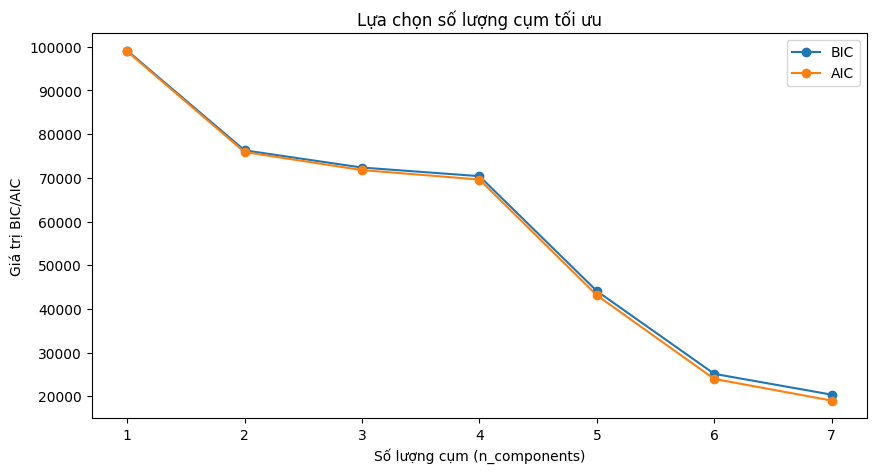

Thống kê trung bình theo từng cụm:
         dien_tich_dat  dien_tich_su_dung  chieu_ngang  tong_so_tang  \
cluster                                                                
0            43.227616         100.557980     3.819050      2.770488   
1            58.913274         162.502542     4.117211      3.820628   
2           120.743190         283.583204     6.155447      3.632933   
3            56.129460         113.662558     5.133708      2.297156   

         so_phong_ngu    gia_ban  
cluster                           
0            2.922652   5.751724  
1            4.901986   9.380330  
2            5.867925  20.537074  
3            2.780689   7.504784  


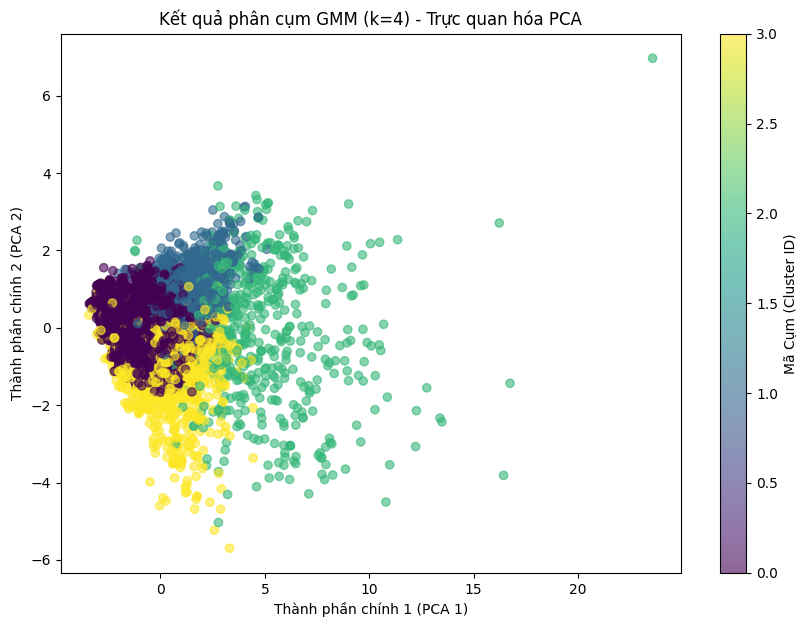

In [60]:
# 1. Tải dữ liệu
df_gmm = pd.read_csv('clustering_data.csv')

# 2. Lựa chọn đặc trưng (Features) để phân cụm
# Chúng ta chọn các biến số quan trọng nhất quyết định phân khúc nhà đất
features = ['dien_tich_dat', 'dien_tich_su_dung', 'chieu_ngang', 'tong_so_tang', 'so_phong_ngu', 'gia_ban']
X = df_gmm[features]

# 3. Tiền xử lý dữ liệu (Scaling)
# Sử dụng RobustScaler vì dữ liệu bất động sản thường có nhiều Outliers (nhà giá siêu cao/thấp)
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

# 4. Xác định số cụm tối ưu bằng chỉ số BIC (Bayesian Information Criterion)
# BIC càng thấp thì mô hình càng tốt
n_components = np.arange(1, 8)
models_gmm = [GaussianMixture(n, covariance_type='full', random_state=42).fit(X_scaled)
          for n in n_components]

plt.figure(figsize=(10, 5))
plt.plot(n_components, [m.bic(X_scaled) for m in models_gmm], label='BIC', marker='o')
plt.plot(n_components, [m.aic(X_scaled) for m in models_gmm], label='AIC', marker='o')
plt.legend(loc='best')
plt.xlabel('Số lượng cụm (n_components)')
plt.ylabel('Giá trị BIC/AIC')
plt.title('Lựa chọn số lượng cụm tối ưu')
plt.show()

# 5. Huấn luyện mô hình GMM (Chọn k=4 dựa trên cấu trúc phân khúc thị trường)
k_optimal = 4
gmm = GaussianMixture(n_components=k_optimal, covariance_type='full', random_state=42)
df_gmm['cluster'] = gmm.fit_predict(X_scaled)

# 6. Thống kê đặc trưng trung bình của từng cụm
cluster_summary = df_gmm.groupby('cluster')[features].mean()
print("Thống kê trung bình theo từng cụm:")
print(cluster_summary)

# 7. Trực quan hóa kết quả bằng PCA (Giảm chiều xuống 2D)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df_gmm['cluster'], cmap='viridis', alpha=0.6)
plt.colorbar(scatter, label='Mã Cụm (Cluster ID)')
plt.title(f'Kết quả phân cụm GMM (k={k_optimal}) - Trực quan hóa PCA')
plt.xlabel('Thành phần chính 1 (PCA 1)')
plt.ylabel('Thành phần chính 2 (PCA 2)')
plt.show()

# Xuất dữ liệu đã gán cụm ra file mới
df_gmm.to_csv('clustering_results_gmm.csv', index=False, encoding='utf-8-sig')

## **Kết luận: Với k=4, các cụm chưa tách biệt xa nhau --> chọn K-Means cho bài toán phân cụm**